In [1]:
# Cell 1. Imports y rutas

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
TABLES_DIR = PROJECT_ROOT / "tables" / "chapter6"
FIGURES_DIR = PROJECT_ROOT / "figures" / "chapter6"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# Cell 2. Cargar predicciones ML del Notebook 05 — MAIN y ROBUST

# MAIN
predictions_path_main = PROCESSED_DATA_DIR / "dataset_cap5_regime_predictions.csv"

if not predictions_path_main.exists():
    raise FileNotFoundError(f"No existe el archivo MAIN: {predictions_path_main}")

df_main = (
    pd.read_csv(predictions_path_main, parse_dates=["date"])
    .sort_values("date")
    .reset_index(drop=True)
)

print("MAIN")
print("Shape:", df_main.shape)
print("Rango fechas:", df_main["date"].min(), "->", df_main["date"].max())
print(df_main["sample_split_main"].value_counts(dropna=False))
display(df_main.head())


# ROBUST
predictions_path_robust = PROCESSED_DATA_DIR / "dataset_cap5_regime_predictions_robust.csv"

if not predictions_path_robust.exists():
    raise FileNotFoundError(f"No existe el archivo ROBUST: {predictions_path_robust}")

df_robust = (
    pd.read_csv(predictions_path_robust, parse_dates=["date"])
    .sort_values("date")
    .reset_index(drop=True)
)

print("\nROBUST")
print("Shape:", df_robust.shape)
print("Rango fechas:", df_robust["date"].min(), "->", df_robust["date"].max())
print(df_robust["sample_split_robust"].value_counts(dropna=False))
display(df_robust.head())

MAIN
Shape: (1356, 9)
Rango fechas: 2021-01-04 00:00:00 -> 2026-04-22 00:00:00
sample_split_main
test    1356
Name: count, dtype: int64


,date,sample_split_main,ret_1d,regime,regime_t_plus_1,regime_pred,proba_0,proba_1,proba_2
0,2021-01-04,test,0.003153,2,0,2,0.030707,0.000937,0.968356
1,2021-01-05,test,-0.000951,0,2,2,0.074493,0.000889,0.924617
2,2021-01-06,test,0.031483,2,2,2,0.002597,0.002011,0.995391
3,2021-01-07,test,0.004242,2,2,2,0.008457,0.001637,0.989905
4,2021-01-08,test,0.002608,2,2,2,0.009446,0.001635,0.988919



ROBUST
Shape: (1613, 9)
Rango fechas: 2020-01-02 00:00:00 -> 2026-04-22 00:00:00
sample_split_robust
test    1613
Name: count, dtype: int64


,date,sample_split_robust,ret_1d,regime,regime_t_plus_1,regime_pred,proba_0,proba_1,proba_2
0,2020-01-02,test,0.014761,0,0,0,0.985743,0.013972,0.000284
1,2020-01-03,test,-0.004613,0,0,0,0.990938,0.008908,0.000154
2,2020-01-06,test,-0.004749,0,0,0,0.990868,0.008887,0.000245
3,2020-01-07,test,-0.002200,0,0,0,0.993975,0.005799,0.000227
4,2020-01-08,test,0.001210,0,0,0,0.992151,0.007565,0.000284


In [3]:
# Cell 3. Validaciones de predicciones ML — MAIN y ROBUST

expected_proba_cols = ["proba_0", "proba_1", "proba_2"]


def validate_prediction_input(df, sample_col, label):
    required_cols = [
        "date",
        sample_col,
        "ret_1d",
        "regime",
        "regime_t_plus_1",
        "regime_pred",
        *expected_proba_cols,
    ]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"{label} - Faltan columnas obligatorias: {missing_cols}")

    if df["regime_pred"].isna().any():
        raise ValueError(f"{label} - Hay NaNs en regime_pred")

    if df[expected_proba_cols].isna().any().any():
        raise ValueError(f"{label} - Hay NaNs en columnas de probabilidad")

    if not np.allclose(df[expected_proba_cols].sum(axis=1), 1.0, atol=1e-6):
        raise ValueError(f"{label} - Las probabilidades no suman aproximadamente 1")

    proba_regimes = {int(col.replace("proba_", "")) for col in expected_proba_cols}
    known_regimes = set(df["regime"].dropna().astype(int).unique()) | set(
        df["regime_t_plus_1"].dropna().astype(int).unique()
    )
    predicted_regimes = set(df["regime_pred"].dropna().astype(int).unique())

    if not predicted_regimes <= known_regimes:
        raise ValueError(
            f"{label} - regime_pred contiene regímenes no observados: "
            f"{sorted(predicted_regimes - known_regimes)}"
        )

    if not known_regimes <= proba_regimes:
        raise ValueError(
            f"{label} - Faltan columnas proba_i para regímenes: "
            f"{sorted(known_regimes - proba_regimes)}"
        )

    print(f"{label} - Columnas de probabilidad:", expected_proba_cols)
    print(f"{label} - Regímenes predichos:", sorted(predicted_regimes))
    print(f"{label} - Validaciones de predicciones OK")


validate_prediction_input(df_main, "sample_split_main", "MAIN")
validate_prediction_input(df_robust, "sample_split_robust", "ROBUST")

MAIN - Columnas de probabilidad: ['proba_0', 'proba_1', 'proba_2']
MAIN - Regímenes predichos: [np.int64(0), np.int64(1), np.int64(2)]
MAIN - Validaciones de predicciones OK
ROBUST - Columnas de probabilidad: ['proba_0', 'proba_1', 'proba_2']
ROBUST - Regímenes predichos: [np.int64(0), np.int64(1), np.int64(2)]
ROBUST - Validaciones de predicciones OK


In [4]:
# Cell 4. Cargar mapping económico régimen → exposición — MAIN y ROBUST

required_map_cols = ["regime", "economic_label", "risk_order", "target_exposure"]


def validate_mapping(regime_mapping, label):
    missing_cols = [col for col in required_map_cols if col not in regime_mapping.columns]
    if missing_cols:
        raise ValueError(f"{label} - Faltan columnas en mapping: {missing_cols}")

    mapping = regime_mapping.copy()
    mapping["regime"] = mapping["regime"].astype(int)
    mapping["risk_order"] = mapping["risk_order"].astype(int)
    mapping["target_exposure"] = mapping["target_exposure"].astype(float)

    if mapping["target_exposure"].isna().any():
        raise ValueError(f"{label} - target_exposure contiene NaNs")

    if not mapping["target_exposure"].between(0, 1).all():
        raise ValueError(f"{label} - target_exposure fuera del rango [0, 1]")

    ordered = mapping.sort_values("risk_order").reset_index(drop=True)
    if ordered.loc[0, "economic_label"] != "low_risk":
        raise ValueError(f"{label} - El primer régimen por risk_order no es low_risk")

    if not np.isclose(ordered.loc[0, "target_exposure"], 1.0, atol=1e-10):
        raise ValueError(f"{label} - low_risk debe tener target_exposure = 1.0")

    exposures_by_label = dict(zip(mapping["economic_label"], mapping["target_exposure"]))
    required_labels = {"low_risk", "medium_risk", "high_risk"}
    missing_labels = required_labels - set(exposures_by_label)
    if missing_labels:
        raise ValueError(f"{label} - Faltan etiquetas económicas: {sorted(missing_labels)}")

    if not (
        exposures_by_label["high_risk"]
        < exposures_by_label["medium_risk"]
        < exposures_by_label["low_risk"]
    ):
        raise ValueError(f"{label} - No se cumple high_risk < medium_risk < low_risk")

    return mapping.sort_values("risk_order").reset_index(drop=True)


# MAIN
mapping_path_main = PROJECT_ROOT / "tables" / "chapter4" / "regime_exposure_mapping.csv"

if not mapping_path_main.exists():
    raise FileNotFoundError(f"No existe el mapping MAIN: {mapping_path_main}")

regime_mapping_main = validate_mapping(pd.read_csv(mapping_path_main), "MAIN")
regime_exposure_map_main = dict(
    zip(regime_mapping_main["regime"], regime_mapping_main["target_exposure"])
)

print("MAIN mapping:")
display(regime_mapping_main)
print(regime_exposure_map_main)


# ROBUST
mapping_path_robust = PROJECT_ROOT / "tables" / "chapter4" / "regime_exposure_mapping_robust.csv"

if not mapping_path_robust.exists():
    raise FileNotFoundError(f"No existe el mapping ROBUST: {mapping_path_robust}")

regime_mapping_robust = validate_mapping(pd.read_csv(mapping_path_robust), "ROBUST")
regime_exposure_map_robust = dict(
    zip(regime_mapping_robust["regime"], regime_mapping_robust["target_exposure"])
)

print("\nROBUST mapping:")
display(regime_mapping_robust)
print(regime_exposure_map_robust)

MAIN mapping:


,regime,economic_label,risk_order,target_exposure,mean_cvar_95_60d,cvar_severity_abs,cvar_low_abs,defensive_alpha,methodology
0,0,low_risk,1,1.000000,-0.018404,0.018404,0.018404,1.0,CVaR_train_abs_ratio
1,2,medium_risk,2,0.590556,-0.031163,0.031163,0.018404,1.0,CVaR_train_abs_ratio
2,1,high_risk,3,0.355552,-0.051761,0.051761,0.018404,1.0,CVaR_train_abs_ratio


{0: 1.0, 2: 0.5905564268560006, 1: 0.3555517372976262}

ROBUST mapping:


,regime,economic_label,risk_order,target_exposure,mean_cvar_95_60d,cvar_severity_abs,cvar_low_abs,defensive_alpha,methodology
0,0,low_risk,1,1.000000,-0.018436,0.018436,0.018436,1.0,CVaR_train_abs_ratio
1,1,medium_risk,2,0.600708,-0.030691,0.030691,0.018436,1.0,CVaR_train_abs_ratio
2,2,high_risk,3,0.388559,-0.047448,0.047448,0.018436,1.0,CVaR_train_abs_ratio


{0: 1.0, 1: 0.6007078845462255, 2: 0.3885593625672601}


In [5]:
# Cell 5. Filtrar periodo out-of-sample — MAIN y ROBUST

# MAIN
df_test_main = df_main[df_main["sample_split_main"] == "test"].copy()
df_test_main = df_test_main.sort_values("date").reset_index(drop=True)

if df_test_main.empty:
    raise ValueError("df_test_main está vacío.")

print("MAIN df_test shape:", df_test_main.shape)
print("MAIN rango:", df_test_main["date"].min(), "->", df_test_main["date"].max())
display(df_test_main.head())


# ROBUST
df_test_robust = df_robust[df_robust["sample_split_robust"] == "test"].copy()
df_test_robust = df_test_robust.sort_values("date").reset_index(drop=True)

if df_test_robust.empty:
    raise ValueError("df_test_robust está vacío.")

print("\nROBUST df_test shape:", df_test_robust.shape)
print("ROBUST rango:", df_test_robust["date"].min(), "->", df_test_robust["date"].max())
display(df_test_robust.head())

MAIN df_test shape: (1356, 9)
MAIN rango: 2021-01-04 00:00:00 -> 2026-04-22 00:00:00


,date,sample_split_main,ret_1d,regime,regime_t_plus_1,regime_pred,proba_0,proba_1,proba_2
0,2021-01-04,test,0.003153,2,0,2,0.030707,0.000937,0.968356
1,2021-01-05,test,-0.000951,0,2,2,0.074493,0.000889,0.924617
2,2021-01-06,test,0.031483,2,2,2,0.002597,0.002011,0.995391
3,2021-01-07,test,0.004242,2,2,2,0.008457,0.001637,0.989905
4,2021-01-08,test,0.002608,2,2,2,0.009446,0.001635,0.988919



ROBUST df_test shape: (1613, 9)
ROBUST rango: 2020-01-02 00:00:00 -> 2026-04-22 00:00:00


,date,sample_split_robust,ret_1d,regime,regime_t_plus_1,regime_pred,proba_0,proba_1,proba_2
0,2020-01-02,test,0.014761,0,0,0,0.985743,0.013972,0.000284
1,2020-01-03,test,-0.004613,0,0,0,0.990938,0.008908,0.000154
2,2020-01-06,test,-0.004749,0,0,0,0.990868,0.008887,0.000245
3,2020-01-07,test,-0.002200,0,0,0,0.993975,0.005799,0.000227
4,2020-01-08,test,0.001210,0,0,0,0.992151,0.007565,0.000284


In [6]:
# Cell 6. Validar cobertura del mapping — MAIN y ROBUST

# MAIN
predicted_regimes_main = set(df_test_main["regime_pred"].dropna().astype(int).unique())
mapped_regimes_main = set(regime_exposure_map_main.keys())
missing_main = predicted_regimes_main - mapped_regimes_main

if missing_main:
    raise ValueError(
        f"MAIN - Regímenes predichos sin mapping: {sorted(missing_main)}"
    )

missing_proba_main = [f"proba_{regime}" for regime in mapped_regimes_main if f"proba_{regime}" not in df_test_main.columns]
if missing_proba_main:
    raise ValueError(f"MAIN - Faltan columnas de probabilidad: {missing_proba_main}")

print("MAIN - Regímenes predichos:", sorted(predicted_regimes_main))
print("MAIN - Mapping completo OK")


# ROBUST
predicted_regimes_robust = set(df_test_robust["regime_pred"].dropna().astype(int).unique())
mapped_regimes_robust = set(regime_exposure_map_robust.keys())
missing_robust = predicted_regimes_robust - mapped_regimes_robust

if missing_robust:
    raise ValueError(
        f"ROBUST - Regímenes predichos sin mapping: {sorted(missing_robust)}"
    )

missing_proba_robust = [f"proba_{regime}" for regime in mapped_regimes_robust if f"proba_{regime}" not in df_test_robust.columns]
if missing_proba_robust:
    raise ValueError(f"ROBUST - Faltan columnas de probabilidad: {missing_proba_robust}")

print("\nROBUST - Regímenes predichos:", sorted(predicted_regimes_robust))
print("ROBUST - Mapping completo OK")

MAIN - Regímenes predichos: [np.int64(0), np.int64(1), np.int64(2)]
MAIN - Mapping completo OK

ROBUST - Regímenes predichos: [np.int64(0), np.int64(1), np.int64(2)]
ROBUST - Mapping completo OK


In [7]:
# Cell 7. Estrategia ML hard classification — MAIN y ROBUST

df_test_main["target_exposure_ml_hard"] = (
    df_test_main["regime_pred"]
    .astype(int)
    .map(regime_exposure_map_main)
)

if df_test_main["target_exposure_ml_hard"].isna().any():
    missing = sorted(
        df_test_main.loc[df_test_main["target_exposure_ml_hard"].isna(), "regime_pred"]
        .dropna()
        .unique()
    )
    raise ValueError(f"MAIN - Regímenes predichos sin exposición hard: {missing}")

print("MAIN - Exposición hard:")
print(df_test_main["target_exposure_ml_hard"].describe())


df_test_robust["target_exposure_ml_hard"] = (
    df_test_robust["regime_pred"]
    .astype(int)
    .map(regime_exposure_map_robust)
)

if df_test_robust["target_exposure_ml_hard"].isna().any():
    missing = sorted(
        df_test_robust.loc[df_test_robust["target_exposure_ml_hard"].isna(), "regime_pred"]
        .dropna()
        .unique()
    )
    raise ValueError(f"ROBUST - Regímenes predichos sin exposición hard: {missing}")

print("\nROBUST - Exposición hard:")
print(df_test_robust["target_exposure_ml_hard"].describe())

MAIN - Exposición hard:
count    1356.000000
mean        0.860053
std         0.199946
min         0.355552
25%         0.590556
50%         1.000000
75%         1.000000
max         1.000000
Name: target_exposure_ml_hard, dtype: float64

ROBUST - Exposición hard:
count    1613.000000
mean        0.822492
std         0.217437
min         0.388559
25%         0.600708
50%         1.000000
75%         1.000000
max         1.000000
Name: target_exposure_ml_hard, dtype: float64


In [8]:
# Cell 8. Estrategia ML probability-weighted — MAIN y ROBUST

# MAIN
for regime in regime_exposure_map_main:
    col = f"proba_{regime}"
    if col not in df_test_main.columns:
        raise ValueError(f"MAIN - Falta columna de probabilidad para régimen {regime}: {col}")

df_test_main["target_exposure_ml_proba"] = 0.0

for regime, exposure in regime_exposure_map_main.items():
    df_test_main["target_exposure_ml_proba"] += (
        df_test_main[f"proba_{regime}"] * exposure
    )

if df_test_main["target_exposure_ml_proba"].isna().any():
    raise ValueError("MAIN - Hay valores nulos en target_exposure_ml_proba.")

if not df_test_main["target_exposure_ml_proba"].between(0, 1).all():
    raise ValueError("MAIN - target_exposure_ml_proba fuera del rango [0, 1].")

print("MAIN - Exposición probabilística:")
print(df_test_main["target_exposure_ml_proba"].describe())


# ROBUST
for regime in regime_exposure_map_robust:
    col = f"proba_{regime}"
    if col not in df_test_robust.columns:
        raise ValueError(f"ROBUST - Falta columna de probabilidad para régimen {regime}: {col}")

df_test_robust["target_exposure_ml_proba"] = 0.0

for regime, exposure in regime_exposure_map_robust.items():
    df_test_robust["target_exposure_ml_proba"] += (
        df_test_robust[f"proba_{regime}"] * exposure
    )

if df_test_robust["target_exposure_ml_proba"].isna().any():
    raise ValueError("ROBUST - Hay valores nulos en target_exposure_ml_proba.")

if not df_test_robust["target_exposure_ml_proba"].between(0, 1).all():
    raise ValueError("ROBUST - target_exposure_ml_proba fuera del rango [0, 1].")

print("\nROBUST - Exposición probabilística:")
print(df_test_robust["target_exposure_ml_proba"].describe())

MAIN - Exposición probabilística:
count    1356.000000
mean        0.851891
std         0.169784
min         0.357444
25%         0.666266
50%         0.958317
75%         0.988178
max         0.997818
Name: target_exposure_ml_proba, dtype: float64

ROBUST - Exposición probabilística:
count    1613.000000
mean        0.817414
std         0.190109
min         0.389214
25%         0.618641
50%         0.927873
75%         0.987590
max         0.997913
Name: target_exposure_ml_proba, dtype: float64


In [9]:
# Cell 9. Aplicar shift operativo para evitar look-ahead — MAIN y ROBUST

# MAIN
df_test_main["strategy_exposure_ml_hard"] = df_test_main["target_exposure_ml_hard"].shift(1)
df_test_main["strategy_exposure_ml_proba"] = df_test_main["target_exposure_ml_proba"].shift(1)

df_test_bt_main = df_test_main.dropna(
    subset=[
        "strategy_exposure_ml_hard",
        "strategy_exposure_ml_proba",
    ]
).copy()

if df_test_bt_main.empty:
    raise ValueError("MAIN - df_test_bt está vacío tras shift(1).")

expected_hard_main = df_test_main["target_exposure_ml_hard"].shift(1).loc[df_test_bt_main.index]
expected_proba_main = df_test_main["target_exposure_ml_proba"].shift(1).loc[df_test_bt_main.index]

if not np.allclose(df_test_bt_main["strategy_exposure_ml_hard"], expected_hard_main):
    raise ValueError("MAIN - strategy_exposure_ml_hard no coincide con shift(1)")

if not np.allclose(df_test_bt_main["strategy_exposure_ml_proba"], expected_proba_main):
    raise ValueError("MAIN - strategy_exposure_ml_proba no coincide con shift(1)")

print("MAIN df_test_bt shape:", df_test_bt_main.shape)

display(
    df_test_bt_main[
        [
            "date",
            "ret_1d",
            "regime",
            "regime_t_plus_1",
            "regime_pred",
            "target_exposure_ml_hard",
            "target_exposure_ml_proba",
            "strategy_exposure_ml_hard",
            "strategy_exposure_ml_proba",
        ]
    ].head()
)


# ROBUST
df_test_robust["strategy_exposure_ml_hard"] = df_test_robust["target_exposure_ml_hard"].shift(1)
df_test_robust["strategy_exposure_ml_proba"] = df_test_robust["target_exposure_ml_proba"].shift(1)

df_test_bt_robust = df_test_robust.dropna(
    subset=[
        "strategy_exposure_ml_hard",
        "strategy_exposure_ml_proba",
    ]
).copy()

if df_test_bt_robust.empty:
    raise ValueError("ROBUST - df_test_bt está vacío tras shift(1).")

expected_hard_robust = df_test_robust["target_exposure_ml_hard"].shift(1).loc[df_test_bt_robust.index]
expected_proba_robust = df_test_robust["target_exposure_ml_proba"].shift(1).loc[df_test_bt_robust.index]

if not np.allclose(df_test_bt_robust["strategy_exposure_ml_hard"], expected_hard_robust):
    raise ValueError("ROBUST - strategy_exposure_ml_hard no coincide con shift(1)")

if not np.allclose(df_test_bt_robust["strategy_exposure_ml_proba"], expected_proba_robust):
    raise ValueError("ROBUST - strategy_exposure_ml_proba no coincide con shift(1)")

print("\nROBUST df_test_bt shape:", df_test_bt_robust.shape)

display(
    df_test_bt_robust[
        [
            "date",
            "ret_1d",
            "regime",
            "regime_t_plus_1",
            "regime_pred",
            "target_exposure_ml_hard",
            "target_exposure_ml_proba",
            "strategy_exposure_ml_hard",
            "strategy_exposure_ml_proba",
        ]
    ].head()
)

MAIN df_test_bt shape: (1355, 13)


,date,ret_1d,regime,regime_t_plus_1,regime_pred,target_exposure_ml_hard,target_exposure_ml_proba,strategy_exposure_ml_hard,strategy_exposure_ml_proba
1,2021-01-05,-0.000951,0,2,2,0.590556,0.620848,0.590556,0.602909
2,2021-01-06,0.031483,2,2,2,0.590556,0.591147,0.590556,0.620848
3,2021-01-07,0.004242,2,2,2,0.590556,0.593634,0.590556,0.591147
4,2021-01-08,0.002608,2,2,2,0.590556,0.594040,0.590556,0.593634
5,2021-01-11,-0.005989,2,2,2,0.590556,0.597343,0.590556,0.594040



ROBUST df_test_bt shape: (1612, 13)


,date,ret_1d,regime,regime_t_plus_1,regime_pred,target_exposure_ml_hard,target_exposure_ml_proba,strategy_exposure_ml_hard,strategy_exposure_ml_proba
1,2020-01-03,-0.004613,0,0,0,1.0,0.996349,1.0,0.994247
2,2020-01-06,-0.004749,0,0,0,1.0,0.996302,1.0,0.996349
3,2020-01-07,-0.002200,0,0,0,1.0,0.997546,1.0,0.996302
4,2020-01-08,0.001210,0,0,0,1.0,0.996806,1.0,0.997546
5,2020-01-09,-0.001001,0,0,0,1.0,0.996548,1.0,0.996806


In [10]:
# Cell 10. Construir retornos de benchmark y estrategias ML — MAIN y ROBUST

# MAIN
df_test_bt_main["benchmark_return"] = df_test_bt_main["ret_1d"]

df_test_bt_main["ml_hard_return"] = (
    df_test_bt_main["strategy_exposure_ml_hard"] * df_test_bt_main["ret_1d"]
)

df_test_bt_main["ml_proba_return"] = (
    df_test_bt_main["strategy_exposure_ml_proba"] * df_test_bt_main["ret_1d"]
)

df_test_bt_main["benchmark_cum"] = np.exp(df_test_bt_main["benchmark_return"].cumsum())
df_test_bt_main["ml_hard_cum"] = np.exp(df_test_bt_main["ml_hard_return"].cumsum())
df_test_bt_main["ml_proba_cum"] = np.exp(df_test_bt_main["ml_proba_return"].cumsum())

print("MAIN retornos OK")
display(
    df_test_bt_main[
        [
            "date",
            "benchmark_return",
            "ml_hard_return",
            "ml_proba_return",
            "benchmark_cum",
            "ml_hard_cum",
            "ml_proba_cum",
        ]
    ].head()
)


# ROBUST
df_test_bt_robust["benchmark_return"] = df_test_bt_robust["ret_1d"]

df_test_bt_robust["ml_hard_return"] = (
    df_test_bt_robust["strategy_exposure_ml_hard"] * df_test_bt_robust["ret_1d"]
)

df_test_bt_robust["ml_proba_return"] = (
    df_test_bt_robust["strategy_exposure_ml_proba"] * df_test_bt_robust["ret_1d"]
)

df_test_bt_robust["benchmark_cum"] = np.exp(df_test_bt_robust["benchmark_return"].cumsum())
df_test_bt_robust["ml_hard_cum"] = np.exp(df_test_bt_robust["ml_hard_return"].cumsum())
df_test_bt_robust["ml_proba_cum"] = np.exp(df_test_bt_robust["ml_proba_return"].cumsum())

print("\nROBUST retornos OK")
display(
    df_test_bt_robust[
        [
            "date",
            "benchmark_return",
            "ml_hard_return",
            "ml_proba_return",
            "benchmark_cum",
            "ml_hard_cum",
            "ml_proba_cum",
        ]
    ].head()
)

MAIN retornos OK


,date,benchmark_return,ml_hard_return,ml_proba_return,benchmark_cum,ml_hard_cum,ml_proba_cum
1,2021-01-05,-0.000951,-0.000562,-0.000573,0.999049,0.999438,0.999427
2,2021-01-06,0.031483,0.018593,0.019546,1.031003,1.018194,1.019154
3,2021-01-07,0.004242,0.002505,0.002508,1.035386,1.020749,1.021713
4,2021-01-08,0.002608,0.001540,0.001548,1.038090,1.022322,1.023296
5,2021-01-11,-0.005989,-0.003537,-0.003557,1.031892,1.018713,1.019662



ROBUST retornos OK


,date,benchmark_return,ml_hard_return,ml_proba_return,benchmark_cum,ml_hard_cum,ml_proba_cum
1,2020-01-03,-0.004613,-0.004613,-0.004586,0.995398,0.995398,0.995424
2,2020-01-06,-0.004749,-0.004749,-0.004731,0.990682,0.990682,0.990726
3,2020-01-07,-0.002200,-0.002200,-0.002192,0.988505,0.988505,0.988556
4,2020-01-08,0.001210,0.001210,0.001207,0.989702,0.989702,0.989751
5,2020-01-09,-0.001001,-0.001001,-0.000998,0.988711,0.988711,0.988763


In [11]:
# Cell 11. Funciones de métricas

def compute_drawdown(cumulative_returns):
    running_max = cumulative_returns.cummax()
    return cumulative_returns / running_max - 1


def historical_var(returns, alpha=0.95):
    return returns.quantile(1 - alpha)


def historical_cvar(returns, alpha=0.95):
    var = historical_var(returns, alpha)
    return returns[returns <= var].mean()


def summarize_strategy(strategy_name, returns, cumulative_returns):
    drawdown = compute_drawdown(cumulative_returns)

    return {
        "strategy": strategy_name,
        "total_return": cumulative_returns.iloc[-1] - 1,
        "mean_daily_return": returns.mean(),
        "daily_volatility": returns.std(),
        "VaR_95": historical_var(returns),
        "CVaR_95": historical_cvar(returns),
        "max_drawdown": drawdown.min(),
    }

In [12]:
# Cell 12. Calcular métricas OOS — MAIN y ROBUST

# MAIN
metrics_ml_main = pd.DataFrame(
    [
        summarize_strategy(
            "Buy & Hold",
            df_test_bt_main["benchmark_return"],
            df_test_bt_main["benchmark_cum"],
        ),
        summarize_strategy(
            "ML hard classification",
            df_test_bt_main["ml_hard_return"],
            df_test_bt_main["ml_hard_cum"],
        ),
        summarize_strategy(
            "ML probability-weighted",
            df_test_bt_main["ml_proba_return"],
            df_test_bt_main["ml_proba_cum"],
        ),
    ]
)

print("MAIN metrics:")
display(metrics_ml_main)


# ROBUST
metrics_ml_robust = pd.DataFrame(
    [
        summarize_strategy(
            "Buy & Hold",
            df_test_bt_robust["benchmark_return"],
            df_test_bt_robust["benchmark_cum"],
        ),
        summarize_strategy(
            "ML hard classification",
            df_test_bt_robust["ml_hard_return"],
            df_test_bt_robust["ml_hard_cum"],
        ),
        summarize_strategy(
            "ML probability-weighted",
            df_test_bt_robust["ml_proba_return"],
            df_test_bt_robust["ml_proba_cum"],
        ),
    ]
)

print("\nROBUST metrics:")
display(metrics_ml_robust)

MAIN metrics:


,strategy,total_return,mean_daily_return,daily_volatility,VaR_95,CVaR_95,max_drawdown
0,Buy & Hold,1.223232,0.000590,0.010258,-0.015877,-0.023772,-0.217647
1,ML hard classification,0.832011,0.000447,0.008172,-0.013261,-0.019126,-0.218747
2,ML probability-weighted,0.784678,0.000427,0.008119,-0.013420,-0.019014,-0.217642



ROBUST metrics:


,strategy,total_return,mean_daily_return,daily_volatility,VaR_95,CVaR_95,max_drawdown
0,Buy & Hold,0.858016,0.000384,0.012733,-0.017651,-0.030660,-0.394343
1,ML hard classification,0.664617,0.000316,0.008724,-0.014358,-0.020754,-0.230611
2,ML probability-weighted,0.596586,0.000290,0.008712,-0.014583,-0.020751,-0.253081


In [13]:
# Cell 13. Drawdowns — MAIN y ROBUST

# MAIN
df_test_bt_main["benchmark_drawdown"] = compute_drawdown(df_test_bt_main["benchmark_cum"])
df_test_bt_main["ml_hard_drawdown"] = compute_drawdown(df_test_bt_main["ml_hard_cum"])
df_test_bt_main["ml_proba_drawdown"] = compute_drawdown(df_test_bt_main["ml_proba_cum"])

print("MAIN drawdowns:")
display(
    df_test_bt_main[
        [
            "date",
            "benchmark_drawdown",
            "ml_hard_drawdown",
            "ml_proba_drawdown",
        ]
    ].head()
)


# ROBUST
df_test_bt_robust["benchmark_drawdown"] = compute_drawdown(df_test_bt_robust["benchmark_cum"])
df_test_bt_robust["ml_hard_drawdown"] = compute_drawdown(df_test_bt_robust["ml_hard_cum"])
df_test_bt_robust["ml_proba_drawdown"] = compute_drawdown(df_test_bt_robust["ml_proba_cum"])

print("\nROBUST drawdowns:")
display(
    df_test_bt_robust[
        [
            "date",
            "benchmark_drawdown",
            "ml_hard_drawdown",
            "ml_proba_drawdown",
        ]
    ].head()
)

MAIN drawdowns:


,date,benchmark_drawdown,ml_hard_drawdown,ml_proba_drawdown
1,2021-01-05,0.000000,0.00000,0.000000
2,2021-01-06,0.000000,0.00000,0.000000
3,2021-01-07,0.000000,0.00000,0.000000
4,2021-01-08,0.000000,0.00000,0.000000
5,2021-01-11,-0.005971,-0.00353,-0.003551



ROBUST drawdowns:


,date,benchmark_drawdown,ml_hard_drawdown,ml_proba_drawdown
1,2020-01-03,0.000000,0.000000,0.000000
2,2020-01-06,-0.004737,-0.004737,-0.004720
3,2020-01-07,-0.006925,-0.006925,-0.006899
4,2020-01-08,-0.005722,-0.005722,-0.005700
5,2020-01-09,-0.006717,-0.006717,-0.006692


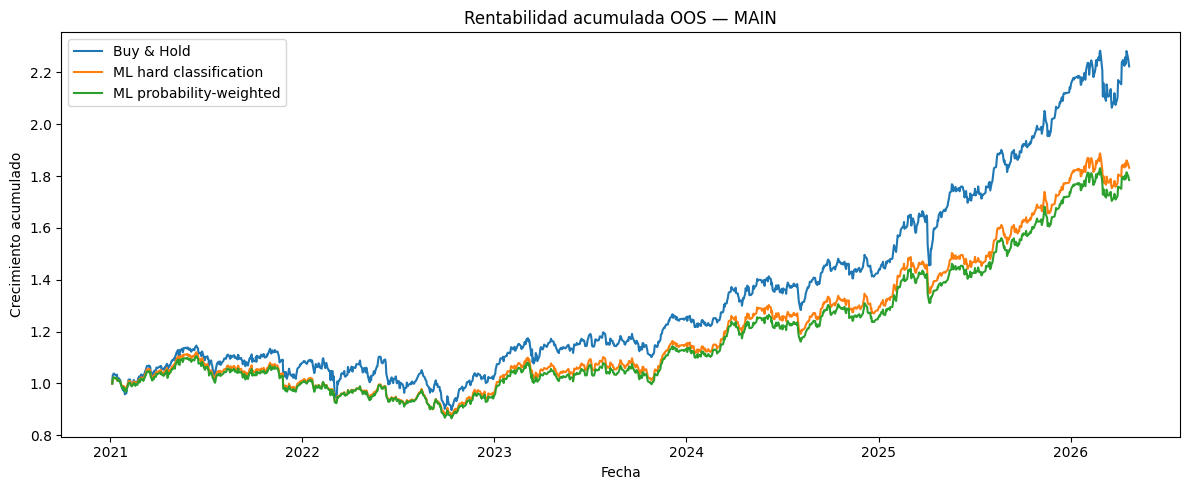

Figura guardada: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/figures/chapter6/ml_oos_cumulative_returns_main.png


In [14]:
# Cell 14. Gráfico de rentabilidad acumulada — MAIN

plt.figure(figsize=(12, 5))

plt.plot(
    df_test_bt_main["date"],
    df_test_bt_main["benchmark_cum"],
    label="Buy & Hold",
)

plt.plot(
    df_test_bt_main["date"],
    df_test_bt_main["ml_hard_cum"],
    label="ML hard classification",
)

plt.plot(
    df_test_bt_main["date"],
    df_test_bt_main["ml_proba_cum"],
    label="ML probability-weighted",
)

plt.title("Rentabilidad acumulada OOS — MAIN")
plt.xlabel("Fecha")
plt.ylabel("Crecimiento acumulado")
plt.legend()
plt.tight_layout()

fig_path = FIGURES_DIR / "ml_oos_cumulative_returns_main.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figura guardada:", fig_path)

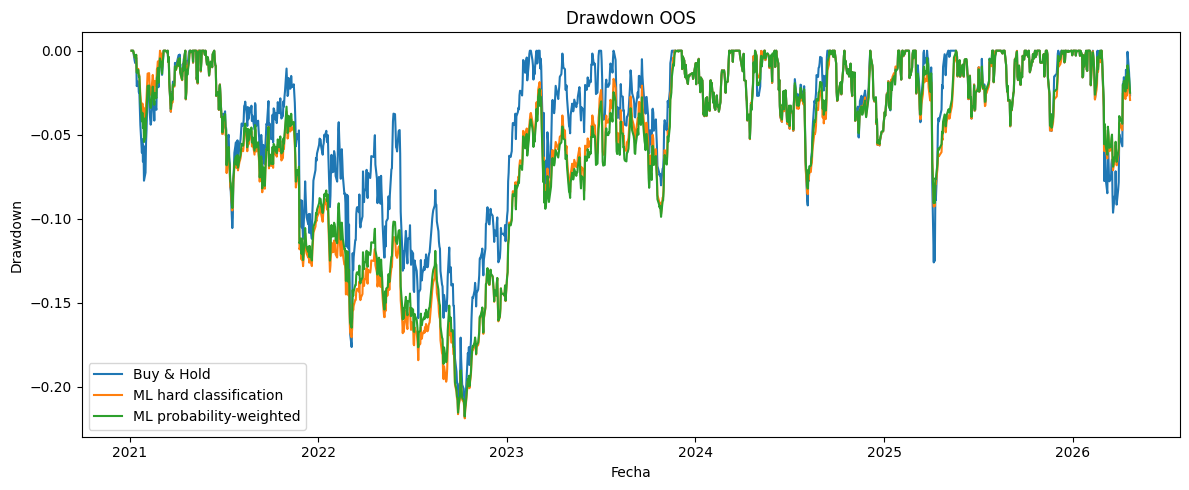

Figura guardada: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/figures/chapter6/ml_oos_drawdown.png


In [15]:
# Cell 15. Gráfico de drawdown — MAIN

plt.figure(figsize=(12, 5))

plt.plot(
    df_test_bt_main["date"],
    df_test_bt_main["benchmark_drawdown"],
    label="Buy & Hold",
)

plt.plot(
    df_test_bt_main["date"],
    df_test_bt_main["ml_hard_drawdown"],
    label="ML hard classification",
)

plt.plot(
    df_test_bt_main["date"],
    df_test_bt_main["ml_proba_drawdown"],
    label="ML probability-weighted",
)

plt.title("Drawdown OOS")
plt.xlabel("Fecha")
plt.ylabel("Drawdown")
plt.legend()
plt.tight_layout()

fig_path = FIGURES_DIR / "ml_oos_drawdown.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figura guardada:", fig_path)

In [16]:
# Cell 17. Comparación de riesgo extremo — MAIN y ROBUST

# MAIN
risk_comparison_main = metrics_ml_main[
    [
        "strategy",
        "daily_volatility",
        "VaR_95",
        "CVaR_95",
        "max_drawdown",
    ]
].copy()

print("MAIN - Comparación de riesgo extremo:")
display(risk_comparison_main)


# ROBUST
risk_comparison_robust = metrics_ml_robust[
    [
        "strategy",
        "daily_volatility",
        "VaR_95",
        "CVaR_95",
        "max_drawdown",
    ]
].copy()

print("\nROBUST - Comparación de riesgo extremo:")
display(risk_comparison_robust)

MAIN - Comparación de riesgo extremo:


,strategy,daily_volatility,VaR_95,CVaR_95,max_drawdown
0,Buy & Hold,0.010258,-0.015877,-0.023772,-0.217647
1,ML hard classification,0.008172,-0.013261,-0.019126,-0.218747
2,ML probability-weighted,0.008119,-0.013420,-0.019014,-0.217642



ROBUST - Comparación de riesgo extremo:


,strategy,daily_volatility,VaR_95,CVaR_95,max_drawdown
0,Buy & Hold,0.012733,-0.017651,-0.030660,-0.394343
1,ML hard classification,0.008724,-0.014358,-0.020754,-0.230611
2,ML probability-weighted,0.008712,-0.014583,-0.020751,-0.253081


In [17]:
# Cell 18. Validaciones finales — MAIN y ROBUST


def validate_backtest_outputs(df_source, df_bt, exposure_map, label):
    if df_bt[["benchmark_return", "ml_hard_return", "ml_proba_return"]].isna().any().any():
        raise ValueError(f"{label} - Hay NaNs en los retornos del backtest.")

    if df_bt[["benchmark_cum", "ml_hard_cum", "ml_proba_cum"]].isna().any().any():
        raise ValueError(f"{label} - Hay NaNs en los acumulados del backtest.")

    expected_rows = len(df_source) - 1
    if len(df_bt) != expected_rows:
        raise ValueError(
            f"{label} - df_bt debería tener {expected_rows} filas tras shift(1), "
            f"pero tiene {len(df_bt)}."
        )

    mapped_hard = df_source["regime_pred"].astype(int).map(exposure_map)
    if not np.allclose(df_source["target_exposure_ml_hard"], mapped_hard):
        raise ValueError(f"{label} - target_exposure_ml_hard no coincide con el mapping")

    expected_proba = pd.Series(0.0, index=df_source.index)
    for regime, exposure in exposure_map.items():
        expected_proba += df_source[f"proba_{regime}"] * exposure

    if not np.allclose(df_source["target_exposure_ml_proba"], expected_proba):
        raise ValueError(
            f"{label} - target_exposure_ml_proba no coincide con la suma ponderada"
        )

    shifted_hard = df_source["target_exposure_ml_hard"].shift(1).loc[df_bt.index]
    shifted_proba = df_source["target_exposure_ml_proba"].shift(1).loc[df_bt.index]

    if df_bt[["strategy_exposure_ml_hard", "strategy_exposure_ml_proba"]].isna().any().any():
        raise ValueError(f"{label} - Hay NaNs en strategy_exposure tras eliminar el primer día")

    if not np.allclose(df_bt["strategy_exposure_ml_hard"], shifted_hard):
        raise ValueError(f"{label} - strategy_exposure_ml_hard no usa shift(1)")

    if not np.allclose(df_bt["strategy_exposure_ml_proba"], shifted_proba):
        raise ValueError(f"{label} - strategy_exposure_ml_proba no usa shift(1)")

    print(f"Validaciones finales {label} OK")
    print(f"df_test_{label.lower()}:", df_source.shape)
    print(f"df_test_bt_{label.lower()}:", df_bt.shape)


validate_backtest_outputs(df_test_main, df_test_bt_main, regime_exposure_map_main, "MAIN")
validate_backtest_outputs(df_test_robust, df_test_bt_robust, regime_exposure_map_robust, "ROBUST")

Validaciones finales MAIN OK
df_test_main: (1356, 13)
df_test_bt_main: (1355, 22)
Validaciones finales ROBUST OK
df_test_robust: (1613, 13)
df_test_bt_robust: (1612, 22)


In [18]:
# Cell 19. Exportar resultados — MAIN y ROBUST

# MAIN
results_path_main = PROCESSED_DATA_DIR / "backtest_ml_results.csv"
metrics_path_main = TABLES_DIR / "ml_performance_metrics.csv"
risk_path_main = TABLES_DIR / "ml_risk_comparison.csv"

df_test_bt_main.to_csv(results_path_main, index=False)
metrics_ml_main.to_csv(metrics_path_main, index=False)
risk_comparison_main.to_csv(risk_path_main, index=False)

print("Exportado MAIN:", results_path_main)
print("Exportado MAIN:", metrics_path_main)
print("Exportado MAIN:", risk_path_main)


# ROBUST
results_path_robust = PROCESSED_DATA_DIR / "backtest_ml_results_robust.csv"
metrics_path_robust = TABLES_DIR / "ml_performance_metrics_robust.csv"
risk_path_robust = TABLES_DIR / "ml_risk_comparison_robust.csv"

df_test_bt_robust.to_csv(results_path_robust, index=False)
metrics_ml_robust.to_csv(metrics_path_robust, index=False)
risk_comparison_robust.to_csv(risk_path_robust, index=False)

print("\nExportado ROBUST:", results_path_robust)
print("Exportado ROBUST:", metrics_path_robust)
print("Exportado ROBUST:", risk_path_robust)

Exportado MAIN: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/data/processed/backtest_ml_results.csv
Exportado MAIN: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter6/ml_performance_metrics.csv
Exportado MAIN: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter6/ml_risk_comparison.csv

Exportado ROBUST: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/data/processed/backtest_ml_results_robust.csv
Exportado ROBUST: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter6/ml_performance_metrics_robust.csv
Exportado ROBUST: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter6/ml_risk_comparison_robust.csv


In [19]:
# Cell 20. Resumen final — MAIN y ROBUST

print("Notebook 06 completado")

print("\nMAIN")
print("Observaciones OOS:", df_test_bt_main.shape[0])
print("Fecha inicio:", df_test_bt_main["date"].min())
print("Fecha fin:", df_test_bt_main["date"].max())
display(metrics_ml_main)

print("\nROBUST")
print("Observaciones OOS:", df_test_bt_robust.shape[0])
print("Fecha inicio:", df_test_bt_robust["date"].min())
print("Fecha fin:", df_test_bt_robust["date"].max())
display(metrics_ml_robust)

Notebook 06 completado

MAIN
Observaciones OOS: 1355
Fecha inicio: 2021-01-05 00:00:00
Fecha fin: 2026-04-22 00:00:00


,strategy,total_return,mean_daily_return,daily_volatility,VaR_95,CVaR_95,max_drawdown
0,Buy & Hold,1.223232,0.000590,0.010258,-0.015877,-0.023772,-0.217647
1,ML hard classification,0.832011,0.000447,0.008172,-0.013261,-0.019126,-0.218747
2,ML probability-weighted,0.784678,0.000427,0.008119,-0.013420,-0.019014,-0.217642



ROBUST
Observaciones OOS: 1612
Fecha inicio: 2020-01-03 00:00:00
Fecha fin: 2026-04-22 00:00:00


,strategy,total_return,mean_daily_return,daily_volatility,VaR_95,CVaR_95,max_drawdown
0,Buy & Hold,0.858016,0.000384,0.012733,-0.017651,-0.030660,-0.394343
1,ML hard classification,0.664617,0.000316,0.008724,-0.014358,-0.020754,-0.230611
2,ML probability-weighted,0.596586,0.000290,0.008712,-0.014583,-0.020751,-0.253081


## Resultados del backtest con estrategias basadas en Machine Learning

Se evalúan tres estrategias en out-of-sample:

- Buy & Hold (benchmark)
- ML hard classification (exposición discreta por régimen)
- ML probability-weighted (exposición continua basada en probabilidades)

El análisis se realiza bajo dos particiones:

- **MAIN** → train hasta 2020, test desde 2021  
- **ROBUST** → train hasta 2019, test desde 2020 (incluye COVID)

---

## Resultados en MAIN

En el escenario MAIN se observa un patrón claro:

- La estrategia ML reduce de forma consistente el riesgo:
  - Menor volatilidad diaria  
  - Mejores niveles de VaR y CVaR  
- Sin embargo, la rentabilidad acumulada es inferior al benchmark  
- El drawdown no mejora de forma significativa

En concreto:

- Volatilidad: ↓ ~15%  
- CVaR: mejora relevante  
- Rentabilidad: ↓ (1.22 → ~0.86)  
- Drawdown: ligeramente peor en ML  

Interpretación:

La estrategia actúa como un mecanismo de **reducción de exposición en fases de incertidumbre**, lo que limita pérdidas extremas pero también reduce la participación en mercados alcistas.

---

## Resultados en ROBUST

Cuando se incluye el periodo 2020 en test, los resultados cambian de forma importante:

- La reducción de riesgo se mantiene:
  - Volatilidad claramente menor  
  - Mejora significativa en VaR y CVaR  
- Aparece una mejora clara en drawdown:
  - Buy & Hold: -39.4%  
  - ML: ~ -25%  
- La rentabilidad sigue siendo inferior

Interpretación:

En entornos de estrés real, la estrategia ML:

- Reduce exposición antes o durante caídas fuertes  
- Evita pérdidas extremas prolongadas  
- Mejora de forma clara la protección de capital  

---

## Comparación MAIN vs ROBUST

La diferencia clave entre ambos escenarios es:

- **MAIN** no incluye una crisis extrema en test  
- **ROBUST** sí incluye el shock de 2020  

Esto provoca que:

- En MAIN → la estrategia parece conservadora pero no especialmente útil  
- En ROBUST → la estrategia muestra su verdadero valor como herramienta de gestión del riesgo extremo  

En otras palabras:

- El modelo no está diseñado para maximizar retornos  
- Está diseñado para **proteger en colas de distribución**

---

## Hard vs Probability-weighted

Entre las dos variantes ML:

- La estrategia probability-weighted:
  - Tiene comportamiento más suave  
  - Reduce ligeramente más el riesgo  
  - Evita cambios bruscos de exposición  
- La estrategia hard:
  - Es más agresiva  
  - Genera mayor rotación implícita  

Las diferencias son pequeñas, pero consistentes a favor del enfoque probabilístico.

---

## Conclusión

Los resultados permiten afirmar que:

- La estrategia basada en regímenes:
  - Reduce volatilidad  
  - Reduce riesgo extremo (VaR y CVaR)  
  - Mejora el comportamiento en crisis (drawdown en ROBUST)  
- A cambio:
  - Reduce la rentabilidad acumulada  

Esto es coherente con el objetivo del modelo:

> No maximizar retornos, sino mejorar la gestión del riesgo extremo mediante una asignación adaptativa basada en el estado del mercado.

### Análisis de sensibilidad del mapping en estrategias ML

En esta sección se replica el análisis de sensibilidad del mapping de exposición para las estrategias basadas en Machine Learning.

El objetivo es comprobar si las conclusiones obtenidas para las estrategias ML se mantienen cuando se utiliza una asignación de exposición más conservadora.

No se modifica el modelo predictivo ni las probabilidades estimadas. Únicamente se cambia la relación entre régimen predicho, probabilidad de régimen y exposición de cartera.

In [20]:
# Sensitivity analysis: alternative exposure mapping for ML strategies

alternative_exposure_by_risk_order = {
    1: 1.00,  # bajo riesgo
    2: 0.50,  # riesgo intermedio
    3: 0.00,  # estrés
}

# Crear mappings alternativos MAIN y ROBUST respetando la interpretación económica
regime_mapping_main_alt = regime_mapping_main.copy()
regime_mapping_robust_alt = regime_mapping_robust.copy()

regime_mapping_main_alt["target_exposure_alt"] = regime_mapping_main_alt["risk_order"].map(
    alternative_exposure_by_risk_order
)

regime_mapping_robust_alt["target_exposure_alt"] = regime_mapping_robust_alt["risk_order"].map(
    alternative_exposure_by_risk_order
)

# Validación
if regime_mapping_main_alt["target_exposure_alt"].isna().any():
    raise ValueError("MAIN: hay risk_order sin mapping alternativo")

if regime_mapping_robust_alt["target_exposure_alt"].isna().any():
    raise ValueError("ROBUST: hay risk_order sin mapping alternativo")

# Diccionarios régimen -> exposición alternativa
regime_exposure_map_main_alt = dict(
    zip(regime_mapping_main_alt["regime"], regime_mapping_main_alt["target_exposure_alt"])
)

regime_exposure_map_robust_alt = dict(
    zip(regime_mapping_robust_alt["regime"], regime_mapping_robust_alt["target_exposure_alt"])
)

print("Mapping alternativo MAIN:")
display(
    regime_mapping_main_alt[
        ["regime", "economic_label", "risk_order", "target_exposure", "target_exposure_alt"]
    ].sort_values("risk_order")
)

print("Mapping alternativo ROBUST:")
display(
    regime_mapping_robust_alt[
        ["regime", "economic_label", "risk_order", "target_exposure", "target_exposure_alt"]
    ].sort_values("risk_order")
)

Mapping alternativo MAIN:


,regime,economic_label,risk_order,target_exposure,target_exposure_alt
0,0,low_risk,1,1.000000,1.0
1,2,medium_risk,2,0.590556,0.5
2,1,high_risk,3,0.355552,0.0


Mapping alternativo ROBUST:


,regime,economic_label,risk_order,target_exposure,target_exposure_alt
0,0,low_risk,1,1.000000,1.0
1,1,medium_risk,2,0.600708,0.5
2,2,high_risk,3,0.388559,0.0


In [21]:
# Aplicar mapping alternativo a ML hard classification — MAIN

df_test_main["target_exposure_ml_hard_alt"] = (
    df_test_main["regime_pred"]
    .astype(int)
    .map(regime_exposure_map_main_alt)
)

if df_test_main["target_exposure_ml_hard_alt"].isna().any():
    raise ValueError("MAIN - Hay valores nulos en target_exposure_ml_hard_alt.")


# Aplicar mapping alternativo a ML probability-weighted — MAIN

df_test_main["target_exposure_ml_proba_alt"] = 0.0

for regime, exposure in regime_exposure_map_main_alt.items():
    df_test_main["target_exposure_ml_proba_alt"] += (
        df_test_main[f"proba_{regime}"] * exposure
    )

if df_test_main["target_exposure_ml_proba_alt"].isna().any():
    raise ValueError("MAIN - Hay valores nulos en target_exposure_ml_proba_alt.")

if not df_test_main["target_exposure_ml_proba_alt"].between(0, 1).all():
    raise ValueError("MAIN - target_exposure_ml_proba_alt fuera del rango [0, 1].")


# Aplicar mapping alternativo a ML hard classification — ROBUST

df_test_robust["target_exposure_ml_hard_alt"] = (
    df_test_robust["regime_pred"]
    .astype(int)
    .map(regime_exposure_map_robust_alt)
)

if df_test_robust["target_exposure_ml_hard_alt"].isna().any():
    raise ValueError("ROBUST - Hay valores nulos en target_exposure_ml_hard_alt.")


# Aplicar mapping alternativo a ML probability-weighted — ROBUST

df_test_robust["target_exposure_ml_proba_alt"] = 0.0

for regime, exposure in regime_exposure_map_robust_alt.items():
    df_test_robust["target_exposure_ml_proba_alt"] += (
        df_test_robust[f"proba_{regime}"] * exposure
    )

if df_test_robust["target_exposure_ml_proba_alt"].isna().any():
    raise ValueError("ROBUST - Hay valores nulos en target_exposure_ml_proba_alt.")

if not df_test_robust["target_exposure_ml_proba_alt"].between(0, 1).all():
    raise ValueError("ROBUST - target_exposure_ml_proba_alt fuera del rango [0, 1].")


print("MAIN - Exposición ML alternativa:")
print(df_test_main[["target_exposure_ml_hard_alt", "target_exposure_ml_proba_alt"]].describe())

print("\nROBUST - Exposición ML alternativa:")
print(df_test_robust[["target_exposure_ml_hard_alt", "target_exposure_ml_proba_alt"]].describe())

MAIN - Exposición ML alternativa:
       target_exposure_ml_hard_alt  target_exposure_ml_proba_alt
count                  1356.000000                   1356.000000
mean                      0.825959                      0.815285
std                       0.253283                      0.217339
min                       0.000000                      0.003930
25%                       0.500000                      0.592298
50%                       1.000000                      0.948909
75%                       1.000000                      0.985492
max                       1.000000                      0.997286

ROBUST - Exposición ML alternativa:
       target_exposure_ml_hard_alt  target_exposure_ml_proba_alt
count                  1613.000000                   1613.000000
mean                      0.763484                      0.757398
std                       0.304555                      0.268652
min                       0.000000                      0.001487
25%                

In [22]:
# Shift operativo — MAIN

df_test_main["strategy_exposure_ml_hard_alt"] = (
    df_test_main["target_exposure_ml_hard_alt"].shift(1)
)

df_test_main["strategy_exposure_ml_proba_alt"] = (
    df_test_main["target_exposure_ml_proba_alt"].shift(1)
)

df_test_bt_main_alt = df_test_main.dropna(
    subset=[
        "strategy_exposure_ml_hard_alt",
        "strategy_exposure_ml_proba_alt",
    ]
).copy()

if df_test_bt_main_alt.empty:
    raise ValueError("MAIN ALT - df_test_bt está vacío tras shift(1).")

print("MAIN ALT shape:", df_test_bt_main_alt.shape)


# Shift operativo — ROBUST

df_test_robust["strategy_exposure_ml_hard_alt"] = (
    df_test_robust["target_exposure_ml_hard_alt"].shift(1)
)

df_test_robust["strategy_exposure_ml_proba_alt"] = (
    df_test_robust["target_exposure_ml_proba_alt"].shift(1)
)

df_test_bt_robust_alt = df_test_robust.dropna(
    subset=[
        "strategy_exposure_ml_hard_alt",
        "strategy_exposure_ml_proba_alt",
    ]
).copy()

if df_test_bt_robust_alt.empty:
    raise ValueError("ROBUST ALT - df_test_bt está vacío tras shift(1).")

print("ROBUST ALT shape:", df_test_bt_robust_alt.shape)

MAIN ALT shape: (1355, 17)
ROBUST ALT shape: (1612, 17)


In [23]:
# Retornos y acumulados alternativos — MAIN

df_test_bt_main_alt["benchmark_return"] = df_test_bt_main_alt["ret_1d"]

df_test_bt_main_alt["ml_hard_return_alt"] = (
    df_test_bt_main_alt["strategy_exposure_ml_hard_alt"] * df_test_bt_main_alt["ret_1d"]
)

df_test_bt_main_alt["ml_proba_return_alt"] = (
    df_test_bt_main_alt["strategy_exposure_ml_proba_alt"] * df_test_bt_main_alt["ret_1d"]
)

df_test_bt_main_alt["ml_hard_cum_alt"] = np.exp(
    df_test_bt_main_alt["ml_hard_return_alt"].cumsum()
)

df_test_bt_main_alt["ml_proba_cum_alt"] = np.exp(
    df_test_bt_main_alt["ml_proba_return_alt"].cumsum()
)

print("MAIN ALT retornos OK")
display(
    df_test_bt_main_alt[
        [
            "date",
            "benchmark_return",
            "ml_hard_return_alt",
            "ml_proba_return_alt",
            "ml_hard_cum_alt",
            "ml_proba_cum_alt",
        ]
    ].head()
)


# Retornos y acumulados alternativos — ROBUST

df_test_bt_robust_alt["benchmark_return"] = df_test_bt_robust_alt["ret_1d"]

df_test_bt_robust_alt["ml_hard_return_alt"] = (
    df_test_bt_robust_alt["strategy_exposure_ml_hard_alt"] * df_test_bt_robust_alt["ret_1d"]
)

df_test_bt_robust_alt["ml_proba_return_alt"] = (
    df_test_bt_robust_alt["strategy_exposure_ml_proba_alt"] * df_test_bt_robust_alt["ret_1d"]
)

df_test_bt_robust_alt["ml_hard_cum_alt"] = np.exp(
    df_test_bt_robust_alt["ml_hard_return_alt"].cumsum()
)

df_test_bt_robust_alt["ml_proba_cum_alt"] = np.exp(
    df_test_bt_robust_alt["ml_proba_return_alt"].cumsum()
)

print("\nROBUST ALT retornos OK")
display(
    df_test_bt_robust_alt[
        [
            "date",
            "benchmark_return",
            "ml_hard_return_alt",
            "ml_proba_return_alt",
            "ml_hard_cum_alt",
            "ml_proba_cum_alt",
        ]
    ].head()
)

MAIN ALT retornos OK


,date,benchmark_return,ml_hard_return_alt,ml_proba_return_alt,ml_hard_cum_alt,ml_proba_cum_alt
1,2021-01-05,-0.000951,-0.000476,-0.000490,0.999525,0.999510
2,2021-01-06,0.031483,0.015742,0.016900,1.015383,1.016546
3,2021-01-07,0.004242,0.002121,0.002122,1.017539,1.018706
4,2021-01-08,0.002608,0.001304,0.001313,1.018867,1.020044
5,2021-01-11,-0.005989,-0.002994,-0.003018,1.015821,1.016971



ROBUST ALT retornos OK


,date,benchmark_return,ml_hard_return_alt,ml_proba_return_alt,ml_hard_cum_alt,ml_proba_cum_alt
1,2020-01-03,-0.004613,-0.004613,-0.004579,0.995398,0.995431
2,2020-01-06,-0.004749,-0.004749,-0.004727,0.990682,0.990737
3,2020-01-07,-0.002200,-0.002200,-0.002190,0.988505,0.988570
4,2020-01-08,0.001210,0.001210,0.001206,0.989702,0.989763
5,2020-01-09,-0.001001,-0.001001,-0.000997,0.988711,0.988777


In [24]:
# Métricas de sensibilidad — ML MAIN

def compute_metrics_from_returns(returns):
    returns = returns.dropna()
    
    cumulative = np.exp(returns.cumsum())
    drawdown = (cumulative / cumulative.cummax()) - 1
    
    var_95 = returns.quantile(0.05)
    cvar_95 = returns[returns <= var_95].mean()
    
    return {
        "total_return": cumulative.iloc[-1] - 1,
        "mean_daily_return": returns.mean(),
        "daily_volatility": returns.std(),
        "VaR_95": var_95,
        "CVaR_95": cvar_95,
        "max_drawdown": drawdown.min(),
    }


ml_sensitivity_main = pd.DataFrame(
    [
        {
            "sample": "MAIN",
            "mapping": "Original (1.0 / 0.75 / 0.25)",
            "strategy": "ML hard classification",
            **compute_metrics_from_returns(df_test_bt_main["ml_hard_return"]),
        },
        {
            "sample": "MAIN",
            "mapping": "Alternative (1.0 / 0.5 / 0.0)",
            "strategy": "ML hard classification",
            **compute_metrics_from_returns(df_test_bt_main_alt["ml_hard_return_alt"]),
        },
        {
            "sample": "MAIN",
            "mapping": "Original (1.0 / 0.75 / 0.25)",
            "strategy": "ML probability-weighted",
            **compute_metrics_from_returns(df_test_bt_main["ml_proba_return"]),
        },
        {
            "sample": "MAIN",
            "mapping": "Alternative (1.0 / 0.5 / 0.0)",
            "strategy": "ML probability-weighted",
            **compute_metrics_from_returns(df_test_bt_main_alt["ml_proba_return_alt"]),
        },
    ]
)

display(ml_sensitivity_main)

,sample,mapping,strategy,total_return,mean_daily_return,daily_volatility,VaR_95,CVaR_95,max_drawdown
0,MAIN,Original (1.0 / 0.75 / 0.25),ML hard classification,0.832011,0.000447,0.008172,-0.013261,-0.019126,-0.218747
1,MAIN,Alternative (1.0 / 0.5 / 0.0),ML hard classification,0.700650,0.000392,0.007812,-0.012881,-0.018519,-0.227176
2,MAIN,Original (1.0 / 0.75 / 0.25),ML probability-weighted,0.784678,0.000427,0.008119,-0.013420,-0.019014,-0.217642
3,MAIN,Alternative (1.0 / 0.5 / 0.0),ML probability-weighted,0.652649,0.000371,0.007694,-0.012729,-0.018161,-0.224528


In [25]:
# Métricas de sensibilidad — ML ROBUST

ml_sensitivity_robust = pd.DataFrame(
    [
        {
            "sample": "ROBUST",
            "mapping": "Original (1.0 / 0.75 / 0.25)",
            "strategy": "ML hard classification",
            **compute_metrics_from_returns(df_test_bt_robust["ml_hard_return"]),
        },
        {
            "sample": "ROBUST",
            "mapping": "Alternative (1.0 / 0.5 / 0.0)",
            "strategy": "ML hard classification",
            **compute_metrics_from_returns(df_test_bt_robust_alt["ml_hard_return_alt"]),
        },
        {
            "sample": "ROBUST",
            "mapping": "Original (1.0 / 0.75 / 0.25)",
            "strategy": "ML probability-weighted",
            **compute_metrics_from_returns(df_test_bt_robust["ml_proba_return"]),
        },
        {
            "sample": "ROBUST",
            "mapping": "Alternative (1.0 / 0.5 / 0.0)",
            "strategy": "ML probability-weighted",
            **compute_metrics_from_returns(df_test_bt_robust_alt["ml_proba_return_alt"]),
        },
    ]
)

display(ml_sensitivity_robust)

,sample,mapping,strategy,total_return,mean_daily_return,daily_volatility,VaR_95,CVaR_95,max_drawdown
0,ROBUST,Original (1.0 / 0.75 / 0.25),ML hard classification,0.664617,0.000316,0.008724,-0.014358,-0.020754,-0.230611
1,ROBUST,Alternative (1.0 / 0.5 / 0.0),ML hard classification,0.621294,0.000300,0.007811,-0.012930,-0.018792,-0.234757
2,ROBUST,Original (1.0 / 0.75 / 0.25),ML probability-weighted,0.596586,0.000290,0.008712,-0.014583,-0.020751,-0.253081
3,ROBUST,Alternative (1.0 / 0.5 / 0.0),ML probability-weighted,0.518273,0.000259,0.007685,-0.013201,-0.018339,-0.237462


In [26]:
ml_exposure_sensitivity = pd.concat(
    [ml_sensitivity_main, ml_sensitivity_robust],
    ignore_index=True,
)

output_path = TABLES_DIR / "ml_exposure_sensitivity.csv"

ml_exposure_sensitivity.to_csv(output_path, index=False)

print(f"Exported: {output_path}")

display(ml_exposure_sensitivity)

Exported: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter6/ml_exposure_sensitivity.csv


,sample,mapping,strategy,total_return,mean_daily_return,daily_volatility,VaR_95,CVaR_95,max_drawdown
0,MAIN,Original (1.0 / 0.75 / 0.25),ML hard classification,0.832011,0.000447,0.008172,-0.013261,-0.019126,-0.218747
1,MAIN,Alternative (1.0 / 0.5 / 0.0),ML hard classification,0.700650,0.000392,0.007812,-0.012881,-0.018519,-0.227176
2,MAIN,Original (1.0 / 0.75 / 0.25),ML probability-weighted,0.784678,0.000427,0.008119,-0.013420,-0.019014,-0.217642
3,MAIN,Alternative (1.0 / 0.5 / 0.0),ML probability-weighted,0.652649,0.000371,0.007694,-0.012729,-0.018161,-0.224528
4,ROBUST,Original (1.0 / 0.75 / 0.25),ML hard classification,0.664617,0.000316,0.008724,-0.014358,-0.020754,-0.230611
5,ROBUST,Alternative (1.0 / 0.5 / 0.0),ML hard classification,0.621294,0.000300,0.007811,-0.012930,-0.018792,-0.234757
6,ROBUST,Original (1.0 / 0.75 / 0.25),ML probability-weighted,0.596586,0.000290,0.008712,-0.014583,-0.020751,-0.253081
7,ROBUST,Alternative (1.0 / 0.5 / 0.0),ML probability-weighted,0.518273,0.000259,0.007685,-0.013201,-0.018339,-0.237462


In [27]:
# Tabla final combinada: Regime-based + ML (MAIN + ROBUST)

# 1. Cargar sensibilidad MAIN del Notebook 04
regime_sensitivity_main = pd.read_csv(TABLES_DIR / "exposure_sensitivity.csv")

# Normalizar nombres de columnas del Notebook 04
regime_sensitivity_main = regime_sensitivity_main.rename(
    columns={
        "mean_return": "mean_daily_return",
        "volatility": "daily_volatility",
    }
)

regime_sensitivity_main["sample"] = "MAIN"
regime_sensitivity_main["strategy"] = "Regime-based"

# 2. Cargar backtest regime-based ROBUST del Notebook 04
regime_robust_bt = pd.read_csv(PROCESSED_DATA_DIR / "backtest_oos_results_robust.csv")

required_cols = ["strategy_return", "strategy_return_alt"]
missing_cols = [c for c in required_cols if c not in regime_robust_bt.columns]

if missing_cols:
    raise ValueError(f"Faltan columnas en backtest_oos_results_robust.csv: {missing_cols}")

# 3. Calcular sensibilidad ROBUST regime-based
regime_sensitivity_robust = pd.DataFrame([
    {
        "sample": "ROBUST",
        "mapping": "Original (1.0 / 0.75 / 0.25)",
        "strategy": "Regime-based",
        **compute_metrics_from_returns(regime_robust_bt["strategy_return"]),
    },
    {
        "sample": "ROBUST",
        "mapping": "Alternative (1.0 / 0.5 / 0.0)",
        "strategy": "Regime-based",
        **compute_metrics_from_returns(regime_robust_bt["strategy_return_alt"]),
    },
])

# 4. Unir regime-based + ML
final_sensitivity_table = pd.concat(
    [
        regime_sensitivity_main,
        regime_sensitivity_robust,
        ml_exposure_sensitivity,
    ],
    ignore_index=True,
)

# 5. Ordenar columnas
final_sensitivity_table = final_sensitivity_table[
    [
        "sample",
        "strategy",
        "mapping",
        "total_return",
        "mean_daily_return",
        "daily_volatility",
        "VaR_95",
        "CVaR_95",
        "max_drawdown",
    ]
].sort_values(["sample", "strategy", "mapping"])

display(final_sensitivity_table)

,sample,strategy,mapping,total_return,mean_daily_return,daily_volatility,VaR_95,CVaR_95,max_drawdown
5,MAIN,ML hard classification,Alternative (1.0 / 0.5 / 0.0),0.700650,0.000392,0.007812,-0.012881,-0.018519,-0.227176
4,MAIN,ML hard classification,Original (1.0 / 0.75 / 0.25),0.832011,0.000447,0.008172,-0.013261,-0.019126,-0.218747
7,MAIN,ML probability-weighted,Alternative (1.0 / 0.5 / 0.0),0.652649,0.000371,0.007694,-0.012729,-0.018161,-0.224528
6,MAIN,ML probability-weighted,Original (1.0 / 0.75 / 0.25),0.784678,0.000427,0.008119,-0.013420,-0.019014,-0.217642
1,MAIN,Regime-based,Alternative (1.0 / 0.5 / 0.0),0.733915,0.000406,0.007798,-0.012880,-0.018420,-0.220422
0,MAIN,Regime-based,Original (1.0 / 0.75 / 0.25),0.852445,0.000455,0.008160,-0.013321,-0.019038,-0.210183
9,ROBUST,ML hard classification,Alternative (1.0 / 0.5 / 0.0),0.621294,0.000300,0.007811,-0.012930,-0.018792,-0.234757
8,ROBUST,ML hard classification,Original (1.0 / 0.75 / 0.25),0.664617,0.000316,0.008724,-0.014358,-0.020754,-0.230611
11,ROBUST,ML probability-weighted,Alternative (1.0 / 0.5 / 0.0),0.518273,0.000259,0.007685,-0.013201,-0.018339,-0.237462
10,ROBUST,ML probability-weighted,Original (1.0 / 0.75 / 0.25),0.596586,0.000290,0.008712,-0.014583,-0.020751,-0.253081


In [28]:
output_path = TABLES_DIR / "full_exposure_sensitivity.csv"

final_sensitivity_table.to_csv(output_path, index=False)

print(f"Exported: {output_path}")

Exported: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter6/full_exposure_sensitivity.csv


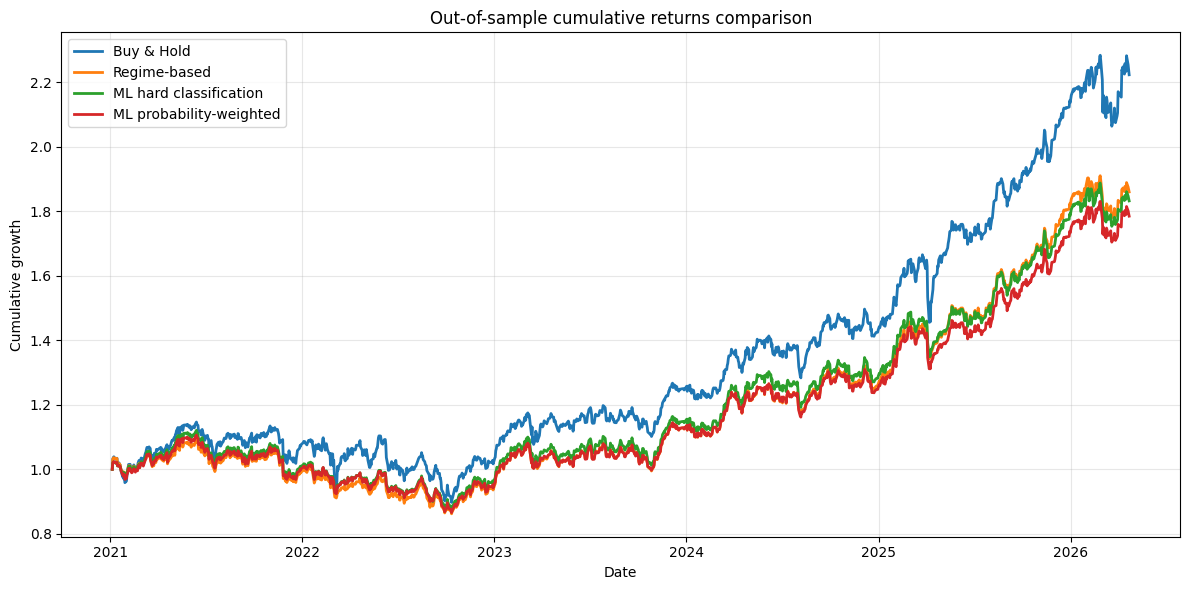

Figura guardada: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/figures/chapter6/cumulative_returns_comparison.png


In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar resultados ML
df_ml = pd.read_csv(
    PROCESSED_DATA_DIR / "backtest_ml_results.csv"
)

# Cargar resultados regime-based
df_regime = pd.read_csv(
    PROCESSED_DATA_DIR / "backtest_oos_results.csv"
)

# Convertir fechas
df_ml["date"] = pd.to_datetime(df_ml["date"])
df_regime["date"] = pd.to_datetime(df_regime["date"])

# Merge por fecha
df_plot = df_ml.merge(
    df_regime[["date", "strategy_cum"]],
    on="date",
    how="left",
)

# Figura
plt.figure(figsize=(12, 6))

plt.plot(
    df_plot["date"],
    df_plot["benchmark_cum"],
    label="Buy & Hold",
    linewidth=2,
)

plt.plot(
    df_plot["date"],
    df_plot["strategy_cum"],
    label="Regime-based",
    linewidth=2,
)

plt.plot(
    df_plot["date"],
    df_plot["ml_hard_cum"],
    label="ML hard classification",
    linewidth=2,
)

plt.plot(
    df_plot["date"],
    df_plot["ml_proba_cum"],
    label="ML probability-weighted",
    linewidth=2,
)

plt.title("Out-of-sample cumulative returns comparison")
plt.xlabel("Date")
plt.ylabel("Cumulative growth")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

fig_path = FIGURES_DIR / "cumulative_returns_comparison.png"

plt.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Figura guardada:", fig_path)

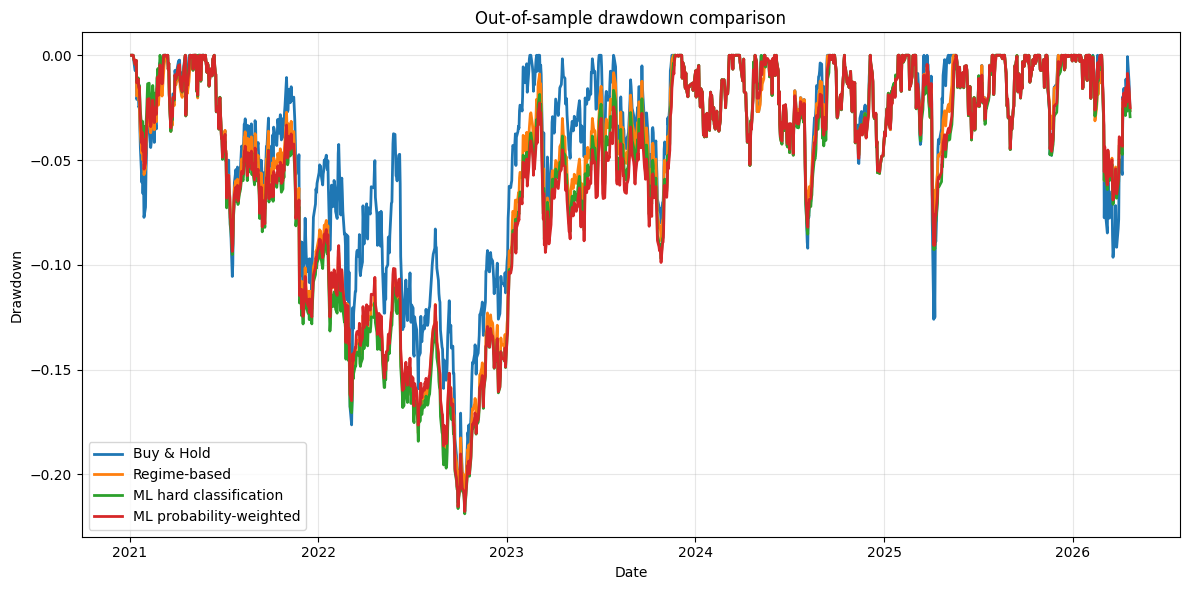

Figura guardada: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/figures/chapter6/drawdown_comparison.png


In [30]:
# Calcular drawdown regime-based
df_plot["regime_drawdown"] = (
    df_plot["strategy_cum"] / df_plot["strategy_cum"].cummax()
) - 1

# Figura
plt.figure(figsize=(12, 6))

plt.plot(
    df_plot["date"],
    df_plot["benchmark_drawdown"],
    label="Buy & Hold",
    linewidth=2,
)

plt.plot(
    df_plot["date"],
    df_plot["regime_drawdown"],
    label="Regime-based",
    linewidth=2,
)

plt.plot(
    df_plot["date"],
    df_plot["ml_hard_drawdown"],
    label="ML hard classification",
    linewidth=2,
)

plt.plot(
    df_plot["date"],
    df_plot["ml_proba_drawdown"],
    label="ML probability-weighted",
    linewidth=2,
)

plt.title("Out-of-sample drawdown comparison")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

fig_path = FIGURES_DIR / "drawdown_comparison.png"

plt.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Figura guardada:", fig_path)

### Interpretación del análisis de sensibilidad en estrategias ML

El análisis de sensibilidad aplicado a las estrategias basadas en Machine Learning confirma que los resultados son robustos a la elección del mapping de exposición.

Al igual que en la estrategia basada en regímenes reales, la utilización de un mapping más conservador reduce de forma sistemática las métricas de riesgo, incluyendo volatilidad, VaR y CVaR, así como el drawdown máximo.

Esta mejora en la protección frente a eventos adversos es especialmente significativa en el escenario ROBUST, lo que refuerza la estabilidad del enfoque en contextos de alta incertidumbre.

No obstante, la reducción del riesgo viene acompañada de una disminución en la rentabilidad total, lo que evidencia nuevamente la existencia de un trade-off entre riesgo y retorno.

En conjunto, estos resultados indican que la eficacia de las estrategias adaptativas no depende de una especificación concreta del mapping, sino de la capacidad del modelo para ajustar dinámicamente la exposición en función del estado del mercado.

In [31]:
# Tablas finales: regime-based + ML en periodo común — MAIN y ROBUST

from pathlib import Path
import numpy as np
import pandas as pd

PROJECT_ROOT = Path("/home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio")

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
TABLES_DIR = PROJECT_ROOT / "tables" / "chapter6"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

ml_bt_main = pd.read_csv(PROCESSED_DATA_DIR / "backtest_ml_results.csv", parse_dates=["date"])
ml_bt_robust = pd.read_csv(PROCESSED_DATA_DIR / "backtest_ml_results_robust.csv", parse_dates=["date"])

regime_bt_main = pd.read_csv(PROCESSED_DATA_DIR / "backtest_oos_results.csv", parse_dates=["date"])
regime_bt_robust = pd.read_csv(PROCESSED_DATA_DIR / "backtest_oos_results_robust.csv", parse_dates=["date"])

ml_main = pd.read_csv(TABLES_DIR / "ml_performance_metrics.csv")
ml_robust = pd.read_csv(TABLES_DIR / "ml_performance_metrics_robust.csv")


def metrics_from_returns(strategy, returns):
    returns = returns.dropna()
    cumulative = np.exp(returns.cumsum())
    drawdown = cumulative / cumulative.cummax() - 1
    var_95 = returns.quantile(0.05)
    cvar_95 = returns[returns <= var_95].mean()
    return {
        "strategy": strategy,
        "total_return": cumulative.iloc[-1] - 1,
        "daily_volatility": returns.std(),
        "VaR_95": var_95,
        "CVaR_95": cvar_95,
        "max_drawdown": drawdown.min(),
    }


def build_final_performance_table(ml_bt, regime_bt, ml_metrics, output_csv):
    common_dates = ml_bt["date"]
    regime_common = regime_bt[regime_bt["date"].isin(common_dates)].copy()

    if len(regime_common) != len(ml_bt):
        raise ValueError("La tabla regime-based no cubre exactamente el periodo ML común")

    final_rows = []
    final_rows.append(
        ml_metrics[ml_metrics["strategy"] == "Buy & Hold"].iloc[0].to_dict()
    )
    final_rows.append(metrics_from_returns("Regime-based", regime_common["strategy_return"]))
    final_rows.extend(
        ml_metrics[
            ml_metrics["strategy"].isin(
                ["ML hard classification", "ML probability-weighted"]
            )
        ].to_dict("records")
    )

    final = pd.DataFrame(final_rows)
    final = final[
        [
            "strategy",
            "total_return",
            "daily_volatility",
            "VaR_95",
            "CVaR_95",
            "max_drawdown",
        ]
    ].rename(
        columns={
            "strategy": "Strategy",
            "total_return": "Total Return",
            "daily_volatility": "Daily Volatility",
            "VaR_95": "VaR 95%",
            "CVaR_95": "CVaR 95%",
            "max_drawdown": "Max Drawdown",
        }
    )

    final = final.round(4)
    final.to_csv(output_csv, index=False)
    return final


final_main = build_final_performance_table(
    ml_bt_main,
    regime_bt_main,
    ml_main,
    TABLES_DIR / "final_performance_metrics_main.csv",
)

final_robust = build_final_performance_table(
    ml_bt_robust,
    regime_bt_robust,
    ml_robust,
    TABLES_DIR / "final_performance_metrics_robust.csv",
)

print("Final performance MAIN:")
display(final_main)
print("\nFinal performance ROBUST:")
display(final_robust)

Final performance MAIN:


,Strategy,Total Return,Daily Volatility,VaR 95%,CVaR 95%,Max Drawdown
0,Buy & Hold,1.2232,0.0103,-0.0159,-0.0238,-0.2176
1,Regime-based,0.8598,0.0082,-0.0133,-0.0190,-0.2102
2,ML hard classification,0.8320,0.0082,-0.0133,-0.0191,-0.2187
3,ML probability-weighted,0.7847,0.0081,-0.0134,-0.0190,-0.2176



Final performance ROBUST:


,Strategy,Total Return,Daily Volatility,VaR 95%,CVaR 95%,Max Drawdown
0,Buy & Hold,0.8580,0.0127,-0.0177,-0.0307,-0.3943
1,Regime-based,0.6053,0.0088,-0.0144,-0.0208,-0.2623
2,ML hard classification,0.6646,0.0087,-0.0144,-0.0208,-0.2306
3,ML probability-weighted,0.5966,0.0087,-0.0146,-0.0208,-0.2531


In [32]:
# Versión compacta para LaTeX — MAIN

final_main_latex = final_main.copy()

final_main_latex["Strategy"] = final_main_latex["Strategy"].replace(
    {
        "ML hard classification": "Hard classification",
        "ML probability-weighted": "Probability-weighted",
    }
)

final_main_latex = final_main_latex.rename(
    columns={
        "Total Return": "Return",
        "Daily Volatility": "Volatility",
        "Max Drawdown": "Max DD",
    }
)

final_main_latex.to_latex(
    TABLES_DIR / "final_performance_metrics_main.tex",
    index=False,
    escape=False,
    float_format="%.4f",
    column_format="lrrrrr",
)

display(final_main_latex)

,Strategy,Return,Volatility,VaR 95%,CVaR 95%,Max DD
0,Buy & Hold,1.2232,0.0103,-0.0159,-0.0238,-0.2176
1,Regime-based,0.8598,0.0082,-0.0133,-0.0190,-0.2102
2,Hard classification,0.8320,0.0082,-0.0133,-0.0191,-0.2187
3,Probability-weighted,0.7847,0.0081,-0.0134,-0.0190,-0.2176


In [33]:
final_robust_latex = final_robust.copy()

final_robust_latex["Strategy"] = final_robust_latex["Strategy"].replace(
    {
        "ML hard classification": "Hard classification",
        "ML probability-weighted": "Probability-weighted",
    }
)

final_robust_latex = final_robust_latex.rename(
    columns={
        "Total Return": "Return",
        "Daily Volatility": "Volatility",
        "Max Drawdown": "Max DD",
    }
)

final_robust_latex.to_latex(
    TABLES_DIR / "final_performance_metrics_robust.tex",
    index=False,
    escape=False,
    float_format="%.4f",
    column_format="lrrrrr",
)

display(final_robust_latex)

,Strategy,Return,Volatility,VaR 95%,CVaR 95%,Max DD
0,Buy & Hold,0.8580,0.0127,-0.0177,-0.0307,-0.3943
1,Regime-based,0.6053,0.0088,-0.0144,-0.0208,-0.2623
2,Hard classification,0.6646,0.0087,-0.0144,-0.0208,-0.2306
3,Probability-weighted,0.5966,0.0087,-0.0146,-0.0208,-0.2531


In [34]:
# Tabla limpia de sensibilidad del mapping

sensitivity_clean = final_sensitivity_table[
    [
        "sample",
        "strategy",
        "mapping",
        "total_return",
        "daily_volatility",
        "CVaR_95",
        "max_drawdown",
    ]
].rename(
    columns={
        "sample": "Sample",
        "strategy": "Strategy",
        "mapping": "Mapping",
        "total_return": "Total Return",
        "daily_volatility": "Volatility",
        "CVaR_95": "CVaR 95%",
        "max_drawdown": "Max Drawdown",
    }
)

sensitivity_clean = sensitivity_clean.round(4)

display(sensitivity_clean)

sensitivity_clean.to_csv(
    TABLES_DIR / "full_exposure_sensitivity_clean.csv",
    index=False,
)

sensitivity_clean.to_latex(
    TABLES_DIR / "full_exposure_sensitivity_clean.tex",
    index=False,
    escape=False,
    float_format="%.4f",
)

print("Exportado:", TABLES_DIR / "full_exposure_sensitivity_clean.tex")

,Sample,Strategy,Mapping,Total Return,Volatility,CVaR 95%,Max Drawdown
5,MAIN,ML hard classification,Alternative (1.0 / 0.5 / 0.0),0.7006,0.0078,-0.0185,-0.2272
4,MAIN,ML hard classification,Original (1.0 / 0.75 / 0.25),0.8320,0.0082,-0.0191,-0.2187
7,MAIN,ML probability-weighted,Alternative (1.0 / 0.5 / 0.0),0.6526,0.0077,-0.0182,-0.2245
6,MAIN,ML probability-weighted,Original (1.0 / 0.75 / 0.25),0.7847,0.0081,-0.0190,-0.2176
1,MAIN,Regime-based,Alternative (1.0 / 0.5 / 0.0),0.7339,0.0078,-0.0184,-0.2204
0,MAIN,Regime-based,Original (1.0 / 0.75 / 0.25),0.8524,0.0082,-0.0190,-0.2102
9,ROBUST,ML hard classification,Alternative (1.0 / 0.5 / 0.0),0.6213,0.0078,-0.0188,-0.2348
8,ROBUST,ML hard classification,Original (1.0 / 0.75 / 0.25),0.6646,0.0087,-0.0208,-0.2306
11,ROBUST,ML probability-weighted,Alternative (1.0 / 0.5 / 0.0),0.5183,0.0077,-0.0183,-0.2375
10,ROBUST,ML probability-weighted,Original (1.0 / 0.75 / 0.25),0.5966,0.0087,-0.0208,-0.2531


Exportado: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter6/full_exposure_sensitivity_clean.tex


In [35]:
# Tabla limpia de stress testing en cola extrema

if "stress" not in globals():
    stress = pd.read_csv(TABLES_DIR / "stress_test_tail_events.csv")

stress_clean = stress.copy()

stress_clean["strategy"] = stress_clean["strategy"].replace(
    {
        "Regime-based strategy": "Regime-based",
    }
)

stress_clean = stress_clean[
    [
        "strategy",
        "mean_return_tail",
        "volatility_tail",
        "worst_day",
        "CVaR_95_tail",
        "total_return_tail",
    ]
].rename(
    columns={
        "strategy": "Strategy",
        "mean_return_tail": "Tail Mean Return",
        "volatility_tail": "Tail Volatility",
        "worst_day": "Worst Day",
        "CVaR_95_tail": "Tail CVaR",
        "total_return_tail": "Cumulative Tail Return",
    }
)

stress_clean = stress_clean.round(4)

display(stress_clean)

stress_clean.to_csv(
    TABLES_DIR / "stress_test_tail_events_clean.csv",
    index=False,
)

stress_clean.to_latex(
    TABLES_DIR / "stress_test_tail_events.tex",
    index=False,
    escape=False,
    float_format="%.4f",
)

print("Exportado:", TABLES_DIR / "stress_test_tail_events.tex")

,Strategy,Tail Mean Return,Tail Volatility,Worst Day,Tail CVaR,Cumulative Tail Return
0,Buy & Hold,-0.0238,0.0097,-0.0601,-0.0526,-0.8014
1,Regime-based,-0.0178,0.0076,-0.0508,-0.0386,-0.7029
2,ML Hard Classification,-0.0180,0.0077,-0.0508,-0.0386,-0.7055
3,ML Probability-Weighted,-0.0182,0.0076,-0.0502,-0.0401,-0.7094


Exportado: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter6/stress_test_tail_events.tex


In [36]:
final_outputs = [
    "final_performance_metrics_main.tex",
    "final_performance_metrics_robust.tex",
    "full_exposure_sensitivity_clean.tex",
    "stress_test_tail_events.tex",
]

for file_name in final_outputs:
    path = TABLES_DIR / file_name
    print(file_name, "->", path.exists(), path)

final_performance_metrics_main.tex -> True /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter6/final_performance_metrics_main.tex
final_performance_metrics_robust.tex -> True /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter6/final_performance_metrics_robust.tex
full_exposure_sensitivity_clean.tex -> True /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter6/full_exposure_sensitivity_clean.tex
stress_test_tail_events.tex -> True /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter6/stress_test_tail_events.tex


In [37]:
# Transaction costs, turnover and risk-adjusted metrics for ML strategies

COST_RATE = 0.001
TRADING_DAYS = 252


def _safe_sharpe(mean_daily_return, daily_volatility):
    if pd.isna(daily_volatility) or np.isclose(daily_volatility, 0.0):
        return np.nan
    return mean_daily_return / daily_volatility * np.sqrt(TRADING_DAYS)


def _safe_return_cvar(total_return, cvar_95):
    if pd.isna(cvar_95) or np.isclose(cvar_95, 0.0):
        return np.nan
    return total_return / abs(cvar_95)


def _performance_metrics_from_returns(returns, strategy, cost_rate=0.0, total_transaction_cost=0.0):
    returns = returns.dropna()
    cumulative = np.exp(returns.cumsum())
    drawdown = cumulative / cumulative.cummax() - 1
    total_return = np.exp(returns.sum()) - 1
    mean_daily_return = returns.mean()
    daily_volatility = returns.std()
    var_95 = returns.quantile(0.05)
    cvar_95 = returns[returns <= var_95].mean()
    max_drawdown = drawdown.min()
    return {
        "strategy": strategy,
        "total_return": total_return,
        "mean_daily_return": mean_daily_return,
        "daily_volatility": daily_volatility,
        "VaR_95": var_95,
        "CVaR_95": cvar_95,
        "max_drawdown": max_drawdown,
        "sharpe_ratio": _safe_sharpe(mean_daily_return, daily_volatility),
        "return_cvar_ratio": _safe_return_cvar(total_return, cvar_95),
        "cost_rate": cost_rate,
        "total_transaction_cost": total_transaction_cost,
    }


def _turnover_metrics(df, sample, strategy, exposure_change_col):
    exposure_change = df[exposure_change_col]
    exposure_changed = exposure_change > 0
    changes_by_year = exposure_changed.groupby(df["date"].dt.year).sum()
    return {
        "sample": sample,
        "strategy": strategy,
        "cost_rate": COST_RATE,
        "total_turnover": exposure_change.sum(),
        "average_daily_turnover": exposure_change.mean(),
        "annualized_turnover": exposure_change.mean() * TRADING_DAYS,
        "exposure_changes_per_year": changes_by_year.mean(),
        "n_exposure_changes": int(exposure_changed.sum()),
        "n_observations": int(len(df)),
    }


def _add_ml_transaction_costs(df):
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])

    required_cols = [
        "strategy_exposure_ml_hard",
        "strategy_exposure_ml_proba",
        "benchmark_return",
        "ml_hard_return",
        "ml_proba_return",
    ]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required ML backtest columns: {missing_cols}")

    for exposure_col in ["strategy_exposure_ml_hard", "strategy_exposure_ml_proba"]:
        if df[exposure_col].isna().any():
            raise ValueError(f"NaN values found in {exposure_col}")
        if not df[exposure_col].between(0, 1).all():
            raise ValueError(f"{exposure_col} outside [0, 1]")

    df["exposure_change_ml_hard"] = df["strategy_exposure_ml_hard"].diff().abs().fillna(0.0)
    df["transaction_cost_ml_hard"] = COST_RATE * df["exposure_change_ml_hard"]
    df["ml_hard_return_net"] = df["ml_hard_return"] - df["transaction_cost_ml_hard"]

    df["exposure_change_ml_proba"] = df["strategy_exposure_ml_proba"].diff().abs().fillna(0.0)
    df["transaction_cost_ml_proba"] = COST_RATE * df["exposure_change_ml_proba"]
    df["ml_proba_return_net"] = df["ml_proba_return"] - df["transaction_cost_ml_proba"]

    checks = [
        (df["exposure_change_ml_hard"].ge(0).all(), "negative ML hard exposure change"),
        (df["exposure_change_ml_proba"].ge(0).all(), "negative ML proba exposure change"),
        (df["transaction_cost_ml_hard"].ge(0).all(), "negative ML hard transaction cost"),
        (df["transaction_cost_ml_proba"].ge(0).all(), "negative ML proba transaction cost"),
        (df.loc[df["exposure_change_ml_hard"].eq(0), "transaction_cost_ml_hard"].eq(0).all(), "ML hard cost when exposure does not change"),
        (df.loc[df["exposure_change_ml_proba"].eq(0), "transaction_cost_ml_proba"].eq(0).all(), "ML proba cost when exposure does not change"),
        (df["ml_hard_return_net"].notna().all(), "NaN in ML hard net returns"),
        (df["ml_proba_return_net"].notna().all(), "NaN in ML proba net returns"),
    ]
    failed_checks = [message for ok, message in checks if not ok]
    if failed_checks:
        raise ValueError(f"Transaction cost validation failed: {failed_checks}")

    return df


def _build_ml_cost_outputs(df, base_metrics, sample):
    df_costs = _add_ml_transaction_costs(df)

    hard_cost = df_costs["transaction_cost_ml_hard"].sum()
    proba_cost = df_costs["transaction_cost_ml_proba"].sum()

    metrics = pd.DataFrame(
        [
            _performance_metrics_from_returns(df_costs["benchmark_return"], "Buy & Hold"),
            _performance_metrics_from_returns(df_costs["ml_hard_return"], "ML Hard gross"),
            _performance_metrics_from_returns(df_costs["ml_hard_return_net"], "ML Hard net of costs", COST_RATE, hard_cost),
            _performance_metrics_from_returns(df_costs["ml_proba_return"], "ML Probability-Weighted gross"),
            _performance_metrics_from_returns(df_costs["ml_proba_return_net"], "ML Probability-Weighted net of costs", COST_RATE, proba_cost),
        ]
    )

    turnover = pd.DataFrame(
        [
            _turnover_metrics(df_costs, sample, "ML Hard Classification", "exposure_change_ml_hard"),
            _turnover_metrics(df_costs, sample, "ML Probability-Weighted", "exposure_change_ml_proba"),
        ]
    )

    gross_name_map = {
        "Buy & Hold": "Buy & Hold",
        "ML Hard gross": "ML hard classification",
        "ML Probability-Weighted gross": "ML probability-weighted",
    }
    metric_cols = ["total_return", "mean_daily_return", "daily_volatility", "VaR_95", "CVaR_95", "max_drawdown"]
    for gross_name, base_name in gross_name_map.items():
        gross_row = metrics.loc[metrics["strategy"].eq(gross_name)].iloc[0]
        base_row = base_metrics.loc[base_metrics["strategy"].eq(base_name)].iloc[0]
        for col in metric_cols:
            if not np.isclose(gross_row[col], base_row[col], atol=1e-12, rtol=1e-10):
                raise ValueError(f"{sample}: gross metric mismatch for {gross_name} / {col}")

    for gross_name, net_name in [
        ("ML Hard gross", "ML Hard net of costs"),
        ("ML Probability-Weighted gross", "ML Probability-Weighted net of costs"),
    ]:
        gross_total = metrics.loc[metrics["strategy"].eq(gross_name), "total_return"].iloc[0]
        net_total = metrics.loc[metrics["strategy"].eq(net_name), "total_return"].iloc[0]
        if net_total > gross_total + 1e-12:
            raise ValueError(f"{sample}: net total return exceeds gross total return for {net_name}")

    return df_costs, metrics, turnover


def _write_simple_latex(df, path, caption, label):
    df.to_latex(
        path,
        index=False,
        escape=False,
        float_format="%.6f",
        caption=caption,
        label=label,
    )


def _final_with_costs_table(ml_metrics, regime_costs, sample):
    regime_net = regime_costs.loc[regime_costs["strategy"].eq("Regime-based net of costs")]
    if regime_net.empty:
        raise ValueError(f"Regime-based net of costs row not found for {sample}")

    selected = pd.concat(
        [
            ml_metrics.loc[ml_metrics["strategy"].eq("Buy & Hold")],
            regime_net,
            ml_metrics.loc[ml_metrics["strategy"].eq("ML Hard net of costs")],
            ml_metrics.loc[ml_metrics["strategy"].eq("ML Probability-Weighted net of costs")],
        ],
        ignore_index=True,
    )

    selected = selected[
        [
            "strategy",
            "total_return",
            "daily_volatility",
            "VaR_95",
            "CVaR_95",
            "max_drawdown",
            "sharpe_ratio",
            "return_cvar_ratio",
            "cost_rate",
            "total_transaction_cost",
        ]
    ].copy()
    selected["sample"] = sample
    return selected[
        [
            "sample",
            "strategy",
            "total_return",
            "daily_volatility",
            "VaR_95",
            "CVaR_95",
            "max_drawdown",
            "sharpe_ratio",
            "return_cvar_ratio",
            "cost_rate",
            "total_transaction_cost",
        ]
    ]


main_ml_backtest = pd.read_csv(PROCESSED_DATA_DIR / "backtest_ml_results.csv")
robust_ml_backtest = pd.read_csv(PROCESSED_DATA_DIR / "backtest_ml_results_robust.csv")
main_base_metrics = pd.read_csv(TABLES_DIR / "ml_performance_metrics.csv")
robust_base_metrics = pd.read_csv(TABLES_DIR / "ml_performance_metrics_robust.csv")

main_costs_df, main_metrics_with_costs, main_turnover = _build_ml_cost_outputs(
    main_ml_backtest,
    main_base_metrics,
    "MAIN",
)
robust_costs_df, robust_metrics_with_costs, robust_turnover = _build_ml_cost_outputs(
    robust_ml_backtest,
    robust_base_metrics,
    "ROBUST",
)

main_metrics_with_costs.to_csv(TABLES_DIR / "ml_performance_metrics_with_costs.csv", index=False)
robust_metrics_with_costs.to_csv(TABLES_DIR / "ml_performance_metrics_with_costs_robust.csv", index=False)
main_turnover.to_csv(TABLES_DIR / "ml_turnover_metrics.csv", index=False)
robust_turnover.to_csv(TABLES_DIR / "ml_turnover_metrics_robust.csv", index=False)

_write_simple_latex(
    main_metrics_with_costs,
    TABLES_DIR / "ml_performance_metrics_with_costs.tex",
    "ML strategy performance metrics with transaction costs, MAIN sample.",
    "tab:ml_performance_metrics_with_costs_main",
)
_write_simple_latex(
    robust_metrics_with_costs,
    TABLES_DIR / "ml_performance_metrics_with_costs_robust.tex",
    "ML strategy performance metrics with transaction costs, ROBUST sample.",
    "tab:ml_performance_metrics_with_costs_robust",
)
_write_simple_latex(
    main_turnover,
    TABLES_DIR / "ml_turnover_metrics.tex",
    "ML strategy turnover metrics, MAIN sample.",
    "tab:ml_turnover_metrics_main",
)
_write_simple_latex(
    robust_turnover,
    TABLES_DIR / "ml_turnover_metrics_robust.tex",
    "ML strategy turnover metrics, ROBUST sample.",
    "tab:ml_turnover_metrics_robust",
)

chapter5_tables_dir = PROJECT_ROOT / "tables" / "chapter5"
main_regime_cost_path = chapter5_tables_dir / "oos_performance_metrics_with_costs.csv"
robust_regime_cost_path = chapter5_tables_dir / "oos_performance_metrics_with_costs_robust.csv"
if not main_regime_cost_path.exists() or not robust_regime_cost_path.exists():
    raise FileNotFoundError("Regime-based cost metrics from Notebook 04 are required for final consolidated cost tables.")

main_regime_costs = pd.read_csv(main_regime_cost_path)
robust_regime_costs = pd.read_csv(robust_regime_cost_path)

final_costs_main = _final_with_costs_table(main_metrics_with_costs, main_regime_costs, "MAIN")
final_costs_robust = _final_with_costs_table(robust_metrics_with_costs, robust_regime_costs, "ROBUST")

final_costs_main.to_csv(TABLES_DIR / "final_performance_metrics_with_costs_main.csv", index=False)
final_costs_robust.to_csv(TABLES_DIR / "final_performance_metrics_with_costs_robust.csv", index=False)
_write_simple_latex(
    final_costs_main,
    TABLES_DIR / "final_performance_metrics_with_costs_main.tex",
    "Final performance comparison with transaction costs, MAIN sample.",
    "tab:final_performance_metrics_with_costs_main",
)
_write_simple_latex(
    final_costs_robust,
    TABLES_DIR / "final_performance_metrics_with_costs_robust.tex",
    "Final performance comparison with transaction costs, ROBUST sample.",
    "tab:final_performance_metrics_with_costs_robust",
)

print("ML performance metrics with costs - MAIN")
display(main_metrics_with_costs)
print("ML turnover metrics - MAIN")
display(main_turnover)
print("ML performance metrics with costs - ROBUST")
display(robust_metrics_with_costs)
print("ML turnover metrics - ROBUST")
display(robust_turnover)
print("Final consolidated performance metrics with costs - MAIN")
display(final_costs_main)
print("Final consolidated performance metrics with costs - ROBUST")
display(final_costs_robust)

ML performance metrics with costs - MAIN


,strategy,total_return,mean_daily_return,daily_volatility,VaR_95,CVaR_95,max_drawdown,sharpe_ratio,return_cvar_ratio,cost_rate,total_transaction_cost
0,Buy & Hold,1.223232,0.000590,0.010258,-0.015877,-0.023772,-0.217647,0.912472,51.456265,0.000,0.000000
1,ML Hard gross,0.832011,0.000447,0.008172,-0.013261,-0.019126,-0.218747,0.867896,43.501084,0.000,0.000000
2,ML Hard net of costs,0.769859,0.000421,0.008173,-0.013395,-0.019162,-0.224531,0.818349,40.176598,0.001,0.034514
3,ML Probability-Weighted gross,0.784678,0.000427,0.008119,-0.013420,-0.019014,-0.217642,0.835824,41.268288,0.000,0.000000
4,ML Probability-Weighted net of costs,0.716125,0.000399,0.008120,-0.013464,-0.019052,-0.226590,0.779234,37.587725,0.001,0.039169


ML turnover metrics - MAIN


,sample,strategy,cost_rate,total_turnover,average_daily_turnover,annualized_turnover,exposure_changes_per_year,n_exposure_changes,n_observations
0,MAIN,ML Hard Classification,0.001,34.514392,0.025472,6.418913,14.333333,86,1355
1,MAIN,ML Probability-Weighted,0.001,39.169076,0.028907,7.284581,225.666667,1354,1355


ML performance metrics with costs - ROBUST


...

,sample,strategy,cost_rate,total_turnover,average_daily_turnover,annualized_turnover,exposure_changes_per_year,n_exposure_changes,n_observations
0,ROBUST,ML Hard Classification,0.001,40.628563,0.025204,6.351363,16.142857,113,1612
1,ROBUST,ML Probability-Weighted,0.001,43.952651,0.027266,6.871010,230.142857,1611,1612


Final consolidated performance metrics with costs - MAIN


,sample,strategy,total_return,daily_volatility,VaR_95,CVaR_95,max_drawdown,sharpe_ratio,return_cvar_ratio,cost_rate,total_transaction_cost
0,MAIN,Buy & Hold,1.223232,0.010258,-0.015877,-0.023772,-0.217647,0.912472,51.456265,0.000,0.000000
1,MAIN,Regime-based net of costs,0.792724,0.008162,-0.013391,-0.019069,-0.216125,0.837303,41.570884,0.001,0.032770
2,MAIN,ML Hard net of costs,0.769859,0.008173,-0.013395,-0.019162,-0.224531,0.818349,40.176598,0.001,0.034514
3,MAIN,ML Probability-Weighted net of costs,0.716125,0.008120,-0.013464,-0.019052,-0.226590,0.779234,37.587725,0.001,0.039169


Final consolidated performance metrics with costs - ROBUST


,sample,strategy,total_return,daily_volatility,VaR_95,CVaR_95,max_drawdown,sharpe_ratio,return_cvar_ratio,cost_rate,total_transaction_cost
0,ROBUST,Buy & Hold,0.858016,0.012733,-0.017651,-0.030660,-0.394343,0.479133,27.985083,0.000,0.000000
1,ROBUST,Regime-based net of costs,0.533846,0.008766,-0.014513,-0.020849,-0.278465,0.480292,25.604976,0.001,0.041477
2,ROBUST,ML Hard net of costs,0.598342,0.008727,-0.014517,-0.020800,-0.244821,0.529189,28.766591,0.001,0.040629
3,ROBUST,ML Probability-Weighted net of costs,0.527932,0.008713,-0.014585,-0.020791,-0.269037,0.479121,25.392616,0.001,0.043953
